In [2]:
# alle grafieken zijn er even uitgecomment, maar moeten later worden terugegeplaatst

In [ ]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

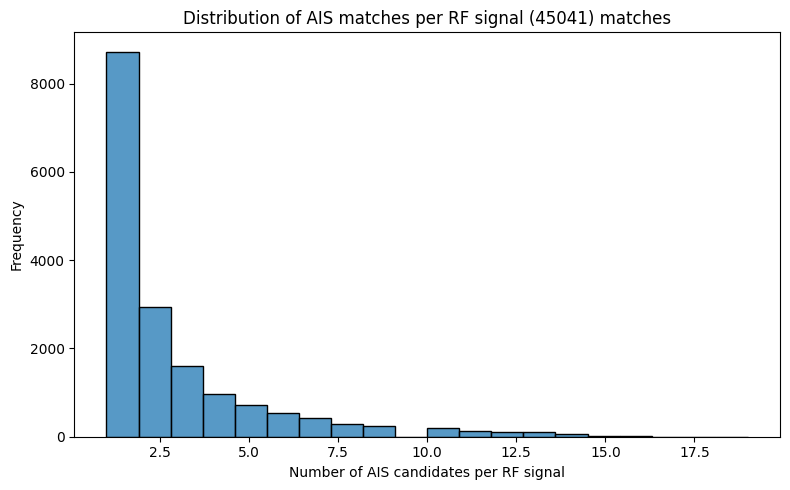

In [346]:


# Data inlezen
df_preselection = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/AIS_RF_preselection_df.pkl")

# Aantal AIS matches per RF-signal
counts = (
    df_preselection
    .groupby(['RF_track_id', 'RF_signal_id'])
    .size()
    .reset_index(name='count')
)

# Histogram plotten
plt.figure(figsize=(8, 5))
sns.histplot(data=counts, x='count', bins=20, kde=False)
plt.xlabel('Number of AIS candidates per RF signal')
plt.ylabel('Frequency')
plt.title(f"Distribution of AIS matches per RF signal ({counts['count'].sum()}) matches")
plt.tight_layout()
plt.show()


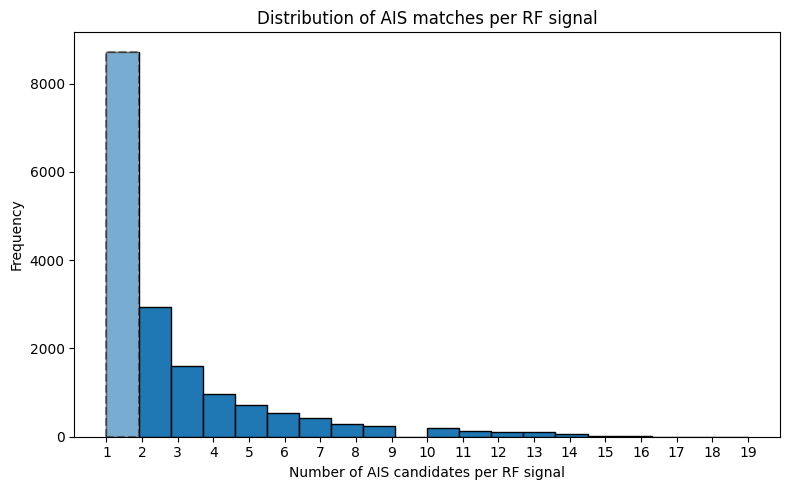

In [349]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Load data
df_preselection = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/AIS_RF_preselection_df.pkl")

# Compute counts per RF signal
counts = (
    df_preselection
    .groupby(['RF_track_id', 'RF_signal_id'])
    .size()
    .reset_index(name='count')
)

# Plot histogram
plt.figure(figsize=(8, 5))
n, bins, patches_list = plt.hist(counts['count'], bins=20, edgecolor='black')

# Style the first bar
first_bin_left = bins[0]
first_bin_right = bins[1]
first_bar_height = n[0]

plt.gca().add_patch(
    patches.Rectangle(
        (first_bin_left, 0),
        first_bin_right - first_bin_left,
        first_bar_height,
        linewidth=1.5,
        edgecolor='black',
        linestyle='--',
        facecolor='white',
        alpha=0.4
    )
)

# Set x-ticks to even integers only
x_min = int(np.floor(bins[0]))
x_max = int(np.ceil(bins[-1]))
even_ticks = [x for x in range(x_min, x_max + 1)]
plt.xticks(even_ticks)

# Labels and title
plt.xlabel('Number of AIS candidates per RF signal')
plt.ylabel('Frequency')
plt.title('Distribution of AIS matches per RF signal')
plt.tight_layout()
plt.show()


In [343]:
counts['count'].sum()

np.int64(45041)

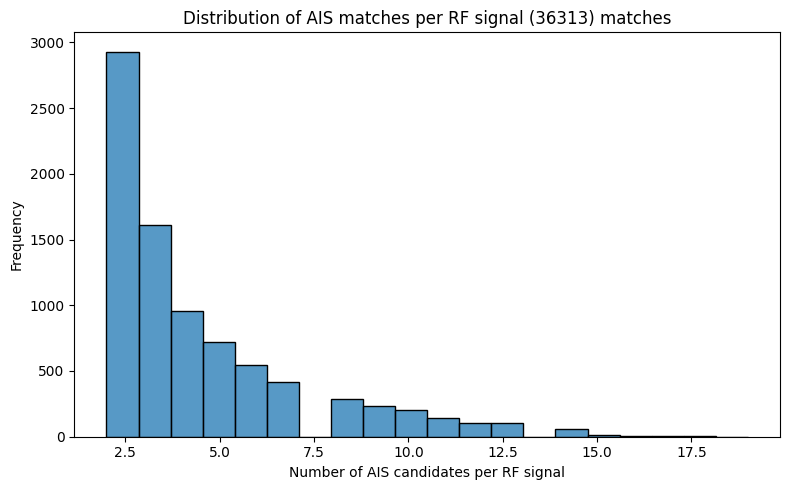

In [347]:
df_preselection_multimatch = df_preselection.groupby(['RF_track_id','RF_signal_id']).filter(lambda x: x['AIS_track_id'].count() > 1)
df_preselection_multimatch = df_preselection_multimatch.reset_index(drop=True)
# Aantal AIS matches per RF-signal
counts = (
    df_preselection_multimatch
    .groupby(['RF_track_id', 'RF_signal_id'])
    .size()
    .reset_index(name='count')
)

# Histogram plotten
plt.figure(figsize=(8, 5))
sns.histplot(data=counts, x='count', bins=20, kde=False)
plt.xlabel('Number of AIS candidates per RF signal')
plt.ylabel('Frequency')
plt.title(f"Distribution of AIS matches per RF signal ({counts['count'].sum()}) matches")
plt.tight_layout()
plt.show()


In [350]:
scores_origineel_correctie = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/forward_scores_origineel_df.pkl")
scores_origineel_correctie_filtered = df_preselection_multimatch.merge(
    scores_origineel_correctie,
    on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
    how='inner',
    suffixes=('', '_y')
)
scores_origineel_correctie_filtered

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-25.584361,-0.036290,-0.069920,True
1,1,"(205717000, 82)","(477706700, 4)",False,-29.461525,-0.043010,-0.082629,False
2,1,"(209087000, 10)","(209087000, 10)",True,-29.016735,-0.032313,-0.063782,True
3,1,"(209087000, 10)","(304888000, 8)",False,-35.083227,-0.056043,-0.106704,False
4,1,"(209087000, 10)","(311008600, 17)",False,-33.164059,-0.070412,-0.130301,False
...,...,...,...,...,...,...,...,...
36308,3,"(671960000, 105)","(377911000, 150)",False,-68.303819,-0.045872,-0.095244,False
36309,3,"(671960000, 105)","(577366000, 65)",False,-117.218514,-0.058609,-0.125334,False
36310,3,"(671960000, 105)","(671960000, 105)",True,-16.599956,-0.038967,-0.071390,True
36311,3,"(671960000, 142)","(311000720, 46)",False,-33.244366,-0.034630,-0.068814,False


In [321]:
scores_correcte_correctie = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/forward_scores_df.pkl")
scores_correcte_correctie_filtered = df_preselection_multimatch.merge(
    scores_correcte_correctie,
    on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
    how='inner',
    suffixes=('', '_y')
)
scores_correcte_correctie_filtered

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-80.616183,-0.114349,-0.220319,True
1,1,"(205717000, 82)","(477706700, 4)",False,-76.412605,-0.111551,-0.214311,False
2,1,"(209087000, 10)","(209087000, 10)",True,-98.424720,-0.109604,-0.216349,True
3,1,"(209087000, 10)","(304888000, 8)",False,-71.952089,-0.114939,-0.218840,False
4,1,"(209087000, 10)","(311008600, 17)",False,-56.565240,-0.120096,-0.222244,False
...,...,...,...,...,...,...,...,...
36308,3,"(671960000, 105)","(377911000, 150)",False,-163.255026,-0.109641,-0.227647,False
36309,3,"(671960000, 105)","(577366000, 65)",False,-224.629066,-0.112315,-0.240181,False
36310,3,"(671960000, 105)","(671960000, 105)",True,-49.315693,-0.115765,-0.212088,True
36311,3,"(671960000, 142)","(311000720, 46)",False,-104.304810,-0.108651,-0.215904,False


In [322]:
scores_geen_correctie = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/forward_scores_df_normal.pkl")
scores_geen_correctie_filtered = df_preselection_multimatch.merge(
    scores_geen_correctie,
    on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
    how='inner',
    suffixes=('', '_y')
)
scores_geen_correctie_filtered

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-43.299102,-0.061417,-0.118334,True
1,1,"(205717000, 82)","(477706700, 4)",False,-43.168521,-0.063020,-0.121073,False
2,1,"(209087000, 10)","(209087000, 10)",True,-51.795451,-0.057679,-0.113853,True
3,1,"(209087000, 10)","(304888000, 8)",False,-43.632995,-0.069701,-0.132708,False
4,1,"(209087000, 10)","(311008600, 17)",False,-36.710588,-0.077942,-0.144236,False
...,...,...,...,...,...,...,...,...
36308,3,"(671960000, 105)","(377911000, 150)",False,-93.442407,-0.062755,-0.130298,False
36309,3,"(671960000, 105)","(577366000, 65)",False,-137.557901,-0.068779,-0.147082,False
36310,3,"(671960000, 105)","(671960000, 105)",True,-27.185129,-0.063815,-0.116913,True
36311,3,"(671960000, 142)","(311000720, 46)",False,-55.838539,-0.058165,-0.115582,False


In [354]:
scores_origineel_correctie_emissie = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/forward_scores_origineel_df.pkl")
scores_origineel_correctie_emissie_filtered = df_preselection_multimatch.merge(
scores_origineel_correctie_emissie,    on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
    how='inner',
    suffixes=('', '_y')
)
scores_origineel_correctie_emissie_filtered

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True
1,1,"(205717000, 82)","(477706700, 4)",False,-29.461525,-0.043010,-0.082629,False
2,1,"(209087000, 10)","(209087000, 10)",True,-29.016735,-0.032313,-0.063782,True
3,1,"(209087000, 10)","(304888000, 8)",False,-35.083227,-0.056043,-0.106704,False
4,1,"(209087000, 10)","(311008600, 17)",False,-33.164059,-0.070412,-0.130301,False
...,...,...,...,...,...,...,...,...
36308,3,"(671960000, 105)","(377911000, 150)",False,-68.303819,-0.045872,-0.095244,False
36309,3,"(671960000, 105)","(577366000, 65)",False,-117.218514,-0.058609,-0.125334,False
36310,3,"(671960000, 105)","(671960000, 105)",True,-16.599956,-0.038967,-0.071390,True
36311,3,"(671960000, 142)","(311000720, 46)",False,-33.244366,-0.034630,-0.068814,False


In [323]:
def get_best_alignments(df, score_col):
    idx = df.groupby(['RF_signal_id', 'RF_track_id'])[score_col].idxmax()
    return df.loc[idx].reset_index(drop=True)[["RF_signal_id", "RF_track_id", "AIS_track_id", "is_true_match", score_col]]

In [355]:
df_best_corrected_og_em = get_best_alignments(scores_origineel_correctie_emissie_filtered, "normalized_forward_score_alpha")
df_best_corrected_og_em.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_alpha
0,1,"(205717000, 82)","(205717000, 82)",True,-0.067843
1,1,"(209087000, 10)","(351567000, 19)",False,-0.063266
2,1,"(209087000, 15)","(209087000, 15)",True,-0.065073
3,1,"(209444000, 0)","(209444000, 0)",True,-0.061355
4,1,"(209690000, 25)","(209690000, 25)",True,-0.061905


In [351]:
df_best_corrected_og = get_best_alignments(scores_origineel_correctie_filtered, "normalized_forward_score_alpha")
df_best_corrected_og.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_alpha
0,1,"(205717000, 82)","(205717000, 82)",True,-0.069920
1,1,"(209087000, 10)","(351567000, 19)",False,-0.063266
2,1,"(209087000, 15)","(209087000, 15)",True,-0.066752
3,1,"(209444000, 0)","(209444000, 0)",True,-0.062123
4,1,"(209690000, 25)","(209690000, 25)",True,-0.061905


In [352]:
df_best_corrected = get_best_alignments(scores_correcte_correctie_filtered, "normalized_forward_score_alpha")
df_best_corrected.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_alpha
0,1,"(205717000, 82)","(477706700, 4)",False,-0.214311
1,1,"(209087000, 10)","(209087000, 10)",True,-0.216349
2,1,"(209087000, 15)","(209087000, 15)",True,-0.213770
3,1,"(209444000, 0)","(209444000, 0)",True,-0.228101
4,1,"(209690000, 25)","(538005708, 34)",False,-0.218605


In [325]:
df_best_not_corrected = get_best_alignments(scores_geen_correctie_filtered, "normalized_forward_score_alpha")
df_best_not_corrected.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_alpha
0,1,"(205717000, 82)","(205717000, 82)",True,-0.118334
1,1,"(209087000, 10)","(351567000, 19)",False,-0.113678
2,1,"(209087000, 15)","(209087000, 15)",True,-0.114656
3,1,"(209444000, 0)","(209444000, 0)",True,-0.116914
4,1,"(209690000, 25)","(209690000, 25)",True,-0.114882


In [327]:
def calculate_precision(df_best):
    TP = df_best["is_true_match"].sum()
    FP = (~df_best["is_true_match"]).sum()
    precision = TP / (TP + FP) 
    return (f"The precision score is: {precision:.4f}")

In [356]:
calculate_precision(df_best_not_corrected), calculate_precision(df_best_corrected), calculate_precision(df_best_corrected_og),calculate_precision(df_best_corrected_og_em)

('The precision score is: 0.7657',
 'The precision score is: 0.5970',
 'The precision score is: 0.8274',
 'The precision score is: 0.8486')

In [257]:
2* np.log(0.3),0.5* np.log(0.3)

(np.float64(-2.4079456086518722), np.float64(-0.6019864021629681))

In [229]:
n_unique_rf_signals = test[['RF_track_id', 'RF_signal_id']].drop_duplicates().shape[0]
n_unique_ais_tracks = test['AIS_track_id'].nunique()
n_unique_rf_signals, n_unique_ais_tracks

(17081, 3194)

In [154]:
test2 = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/train_data_sample_5000.pkl")

In [226]:
test[["RF_signal_id", "RF_track_id"]].nunique()

RF_signal_id      41
RF_track_id     3192
dtype: int64

In [218]:
test[(test["RF_signal_id"] == 41) & (test["RF_track_id"] == (366904890, 0))]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match
19090,41,"(366904890, 0)","(316001701, 19)",False
19091,41,"(366904890, 0)","(316004910, 34)",False
19092,41,"(366904890, 0)","(366893910, 3)",False
19093,41,"(366904890, 0)","(366904890, 0)",True
19094,41,"(366904890, 0)","(366904910, 1)",False
19095,41,"(366904890, 0)","(366904930, 2)",False
19096,41,"(366904890, 0)","(366938770, 0)",False
19097,41,"(366904890, 0)","(366938780, 0)",False
19098,41,"(366904890, 0)","(367050160, 2)",False
19099,41,"(366904890, 0)","(367121010, 0)",False


In [ ]:
# Calculate the average number of AIS tracks linked to each RF track 
AIS_tracks_per_RF_signal = test.groupby(["RF_signal_id", "RF_track_id"])["AIS_track_id"].nunique()
average_AIS_matches_per_RF_signal = AIS_tracks_per_RF_signal.mean()
print(f"Average number of AIS tracks per RF track: {average_AIS_matches_per_RF_signal:.2f}")c

Average number of AIS tracks per RF track: 2.64


In [201]:
for i, (a,b,c) in test[['RF_signal_id', 'RF_track_id', 'AIS_track_id']].iterrows():
    print(a,b,c)

1 (205717000, 3) (205717000, 3)
2 (205717000, 3) (205717000, 3)
3 (205717000, 3) (205717000, 3)
4 (205717000, 3) (205717000, 3)
1 (205717000, 7) (205717000, 7)
2 (205717000, 7) (205717000, 7)
1 (205717000, 82) (205717000, 82)
1 (205717000, 82) (477706700, 4)
2 (205717000, 82) (205717000, 82)
3 (205717000, 82) (205717000, 82)
4 (205717000, 82) (205717000, 82)
1 (209017000, 19) (209017000, 19)
1 (209017000, 23) (209017000, 23)
1 (209087000, 10) (209087000, 10)
1 (209087000, 10) (304888000, 8)
1 (209087000, 10) (311008600, 17)
1 (209087000, 10) (351567000, 19)
2 (209087000, 10) (209087000, 10)
2 (209087000, 10) (304888000, 8)
2 (209087000, 10) (311008600, 17)
2 (209087000, 10) (351567000, 19)
3 (209087000, 10) (209087000, 10)
3 (209087000, 10) (304888000, 8)
3 (209087000, 10) (305803000, 20)
3 (209087000, 10) (311008600, 17)
3 (209087000, 10) (351567000, 19)
4 (209087000, 10) (209087000, 10)
4 (209087000, 10) (304888000, 8)
4 (209087000, 10) (305803000, 20)
4 (209087000, 10) (351567000, 1

KeyboardInterrupt: 

In [191]:
AIS_seq = [(dt, coord) for dt, coord in zip(g["AIS_Timestamp"], g["AIS"])
           if pd.notna(dt) and coord is not None]
len(AIS_seq)

378

In [159]:
test

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match
0,1,"(205717000, 3)","(205717000, 3)",True
1,2,"(205717000, 3)","(205717000, 3)",True
2,3,"(205717000, 3)","(205717000, 3)",True
3,4,"(205717000, 3)","(205717000, 3)",True
4,1,"(205717000, 7)","(205717000, 7)",True
...,...,...,...,...
45036,3,"(750000045, 1)","(750000045, 1)",True
45037,4,"(750000045, 1)","(750000045, 1)",True
45038,5,"(750000045, 1)","(750000045, 1)",True
45039,6,"(750000045, 1)","(750000045, 1)",True


In [210]:
df_RF = test2[test2["RF"].notna()].copy()
df_RF["RF_signal_id"] = df_RF.groupby("ID").cumcount() + 1
df_RF

RF_data = df_RF[(df_RF["RF_signal_id"] == 1) & (df_RF["ID"] == (205717000, 3))]
RF_datetime = RF_data["RF_Timestamp"]
RF_coordinates = RF_data["RF"]

In [213]:
RF_coordinates.values[0]

[46.905132569730185, -124.90139157632149]

In [169]:
test4 = pd.merge(df_RF, test, left_on=["ID", "RF_signal_id"], right_on=["RF_track_id", "RF_signal_id"])
test4

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State,RF_signal_id,RF_track_id,AIS_track_id,is_true_match
0,"(205717000, 3)",3,205717000,2024-01-01 05:08:47,NaT,2024-01-01 05:08:47,None,"[46.905132569730185, -124.90139157632149]",RF,1,"(205717000, 3)","(205717000, 3)",True
1,"(205717000, 3)",3,205717000,2024-01-01 08:26:02,NaT,2024-01-01 08:26:02,None,"[46.928140679836154, -124.13749162721079]",RF,2,"(205717000, 3)","(205717000, 3)",True
2,"(205717000, 3)",3,205717000,2024-01-01 11:40:10,NaT,2024-01-01 11:40:10,None,"[46.904036021256516, -124.11232821381113]",RF,3,"(205717000, 3)","(205717000, 3)",True
3,"(205717000, 3)",3,205717000,2024-01-01 15:27:16,NaT,2024-01-01 15:27:16,None,"[46.91037655705591, -124.09487022207654]",RF,4,"(205717000, 3)","(205717000, 3)",True
4,"(205717000, 7)",7,205717000,2024-01-02 05:08:47,NaT,2024-01-02 05:08:47,None,"[46.93875892283727, -124.10578073281896]",RF,1,"(205717000, 7)","(205717000, 7)",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45036,"(750000045, 1)",1,750000045,2024-01-07 08:26:02,NaT,2024-01-07 08:26:02,None,"[17.24017345990615, -66.40110676876083]",RF,3,"(750000045, 1)","(750000045, 1)",True
45037,"(750000045, 1)",1,750000045,2024-01-07 11:40:10,NaT,2024-01-07 11:40:10,None,"[17.270589540988656, -66.95231081591118]",RF,4,"(750000045, 1)","(750000045, 1)",True
45038,"(750000045, 1)",1,750000045,2024-01-07 15:27:16,NaT,2024-01-07 15:27:16,None,"[17.431092666494642, -67.51508429815706]",RF,5,"(750000045, 1)","(750000045, 1)",True
45039,"(750000045, 1)",1,750000045,2024-01-07 19:11:03,NaT,2024-01-07 19:11:03,None,"[17.647977938544923, -68.05909799161111]",RF,6,"(750000045, 1)","(750000045, 1)",True


In [156]:
for RF_track_id, AIS_track_id in test.iterrows():
    print(RF_track_id, AIS_track_id)
    break
    

0 RF_signal_id                  1
RF_track_id      (205717000, 3)
AIS_track_id     (205717000, 3)
is_true_match              True
Name: 0, dtype: object


In [152]:
# Calculate the average number of AIS tracks linked to each RF track 
AIS_tracks_per_RF_signal = test.groupby(["RF_signal_id", "RF_track_id"])["AIS_track_id"].nunique()
average_AIS_matches_per_RF_signal = AIS_tracks_per_RF_signal.mean()
print(f"Average number of AIS tracks per RF track: {average_AIS_matches_per_RF_signal:.2f}")

Average number of AIS tracks per RF track: 2.64


In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random
import numpy as np 
import math
from haversine import haversine, Unit

from scripts.visualization.map_vessel_routes_v2 import * 

from scripts.PHMM.distributions.AIS_RF_distribution import * 
from scripts.PHMM.distributions.match_distribution import * 

from scripts.PHMM.viterbi_algorithm.states import *
from scripts.PHMM.viterbi_algorithm.forward import *
from scripts.PHMM.viterbi_algorithm.viterbi import *

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
# laat gefilterde cargo data

df_cargo = pd.read_parquet("../../data/processed/cargo_vessels.parquet")
relevant_columns = ["MMSI", "IMO", "BaseDateTime", "LAT", "LON", "SOG", "Heading"]
df_cargo = df_cargo[relevant_columns].reset_index(drop=True)

# converteer snelheden van 'SOG' van knopen naar km/u (1 knots is 1.852 km/u)

df_cargo["SOG_kph"] = df_cargo["SOG"] * 1.852

df_cargo.head(5)

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,SOG_kph
0,367121040,IMO7634226,2024-01-01 00:00:03,41.54617,-82.72934,0.0,184.0,0.0000
1,212719000,IMO9698238,2024-01-01 00:00:02,34.52975,-120.94588,10.4,322.0,19.2608
2,367050160,IMO7514713,2024-01-01 00:00:03,46.75197,-92.13539,0.0,137.0,0.0000
3,538007479,IMO9347542,2024-01-01 00:00:06,37.68875,-122.69553,6.0,7.0,11.1120
4,477133500,IMO9638434,2024-01-01 00:00:02,38.07199,-124.04890,13.1,327.0,24.2612


In [5]:
# # plot coverage area
# plot_coverage_area()

In [6]:
# plot voorbeeld route
plot_AIS_route(df_cargo, 538009071)

In [7]:
# # plot de verdeling van het aantal observaties per route

# route_lengths = df_cargo.groupby(["MMSI"]).size().reset_index(name = "length")

# bins = [0, 5, 10, 50, 100, 500, 1000, 2000, 5000, 10000, 20000, np.inf]
# labels = ["0-5", "5-10", "10-50", "50-100", "100-500", "500-1000", "1000-2000", "2000-5000", "5000-10000", "10000-20000", ">20000"]

# route_lengths["length_bins"] = pd.cut(route_lengths["length"], bins = bins, labels = labels, right = False)

# bin_counts_len_route = route_lengths["length_bins"].value_counts().sort_index().reset_index()
# bin_counts_len_route.columns = ["length_bins", "count"]

# plt.figure(figsize = (13, 5))
# sns.barplot(data = bin_counts_len_route,  x = "length_bins", y = "count", palette = "viridis")

# for i, row in bin_counts_len_route.iterrows():
#     plt.text(i, row["count"] + 1, str(row["count"]), ha = "center", va = "bottom")

# plt.title("Distribution of route length")
# plt.xlabel("Number of observations per route (binned)")
# plt.ylabel("Number of routes")
# plt.show()


In [8]:
# verwijder routes die minder dan 5 data punten hebben (dit zijn 73)

route_lengths = df_cargo.groupby(["MMSI"]).size().reset_index(name = "length")
valid_MMSI = route_lengths[route_lengths["length"] > 5]["MMSI"]
df_filtered_by_route_length = df_cargo[df_cargo["MMSI"].isin(valid_MMSI)].copy()
df_filtered_by_route_length.head(5)

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,SOG_kph
0,367121040,IMO7634226,2024-01-01 00:00:03,41.54617,-82.72934,0.0,184.0,0.0000
1,212719000,IMO9698238,2024-01-01 00:00:02,34.52975,-120.94588,10.4,322.0,19.2608
2,367050160,IMO7514713,2024-01-01 00:00:03,46.75197,-92.13539,0.0,137.0,0.0000
3,538007479,IMO9347542,2024-01-01 00:00:06,37.68875,-122.69553,6.0,7.0,11.1120
4,477133500,IMO9638434,2024-01-01 00:00:02,38.07199,-124.04890,13.1,327.0,24.2612


In [9]:
# # check wat de onrealistische route was, die opeens van normale positie naar abnormale positie ging 

# i = df_filtered_by_route_length[
#     (df_filtered_by_route_length["MMSI"] == 538005048) & 
#     (df_filtered_by_route_length["LAT"].between(0, 1))
# ].index[0]

# # plot deze route
# plot_AIS_route(df_filtered_by_route_length, 538005048)

In [10]:
# bereken speed op basis van tijd en afstand verschil tussen i en i-1

df_speed = df_filtered_by_route_length.copy()

df_speed = df_speed.sort_values(["MMSI", "BaseDateTime"]).reset_index(drop=True)
df_speed["TimeDiff"] = df_speed.groupby("MMSI")["BaseDateTime"].diff().dt.total_seconds()

df_speed["prevLAT"] = df_speed.groupby("MMSI")["LAT"].shift(1)
df_speed["prevLON"] = df_speed.groupby("MMSI")["LON"].shift(1)

def compute_distance_to_previous_point(row):
    return haversine((row["LAT"], row["LON"]), (row["prevLAT"], row["prevLON"]))

df_speed["DistanceDiff"] = df_speed.apply(compute_distance_to_previous_point, axis=1)

df_speed["Speedkph"] = np.where(
    (df_speed["TimeDiff"] > 0) & (df_speed["DistanceDiff"] > 0),
    (df_speed["DistanceDiff"] / df_speed["TimeDiff"]) * 3600,
    0
)
df_speed.head(5)

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,SOG_kph,TimeDiff,prevLAT,prevLON,DistanceDiff,Speedkph
0,205717000,IMO9748485,2024-01-01 02:42:35,46.89866,-125.72790,13.2,92.0,24.4464,NaN,NaN,NaN,NaN,0.000000
1,205717000,IMO9748485,2024-01-01 03:09:33,46.89496,-125.59250,13.6,95.0,25.1872,1618.0,46.89866,-125.72790,10.296077,22.908453
2,205717000,IMO9748485,2024-01-01 03:10:44,46.89473,-125.58606,13.6,95.0,25.1872,71.0,46.89496,-125.59250,0.490005,24.845311
3,205717000,IMO9748485,2024-01-01 03:20:54,46.89337,-125.52966,13.8,93.0,25.5576,610.0,46.89473,-125.58606,4.288228,25.307573
4,205717000,IMO9748485,2024-01-01 03:23:14,46.89343,-125.51669,13.7,93.0,25.3724,140.0,46.89337,-125.52966,0.985561,25.343009


In [11]:
# # maak boxplot van de gemiddelde snelheid per schip voor het verwijderen van de outliers

# avg_speeds = df_speed.groupby("MMSI")["Speedkph"].mean().reset_index()

# sns.boxplot(data = avg_speeds, x = "Speedkph")
# sns.stripplot(data = avg_speeds, x = "Speedkph", alpha=0.4, jitter=True)
# plt.title("Gemiddelde snelheid per schip (voor outlier removal)")
# plt.xlabel("Snelheid (km/u)")
# plt.show()

In [12]:
# verwijder outliers 'speed_kph' column (outliers aan de rechterkant, high speeds)

# gebaseerd op deze strategie:
# https://medium.com/@noorfatimaafzalbutt/outliers-detection-and-removal-using-iqr-method-e629aa8089a8 

Q1 = df_speed["Speedkph"].quantile(0.25)
Q3 = df_speed["Speedkph"].quantile(0.75)
IQR = Q3 - Q1 

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

df_speed["is_high_speed_outlier"] = df_speed["Speedkph"] > upper_limit

high_speed_outliers = (df_speed.loc[df_speed["is_high_speed_outlier"], ["MMSI"]].drop_duplicates())
df_speed_filtered = df_speed[~df_speed["MMSI"].isin(high_speed_outliers["MMSI"])]

# verwijder outliers 'speed' column (outliers aan de linkerkant, low speeds) 
# ZORG DAT JE DE 5 KM DREMPEL AANPAST NAAR EEN VARIABLE DIE GEKOZEN KAN WORDEN

avg_speed_per_ship = df_speed_filtered.groupby("MMSI")["Speedkph"].mean().reset_index()
valid_avg_speed = avg_speed_per_ship[avg_speed_per_ship["Speedkph"] >= 5]["MMSI"]
df_speed_filtered = df_speed_filtered[df_speed_filtered["MMSI"].isin(valid_avg_speed)]

In [13]:
# # maak boxplot van de gemiddelde snelheid per schip na outliers removal

# avg_speeds_filtered = df_speed_filtered.groupby("MMSI")["Speedkph"].mean().reset_index()

# sns.boxplot(data = avg_speeds_filtered, x = "Speedkph")
# sns.stripplot(data = avg_speeds_filtered, x = "Speedkph", alpha=0.4, jitter=True)
# plt.title("Gemiddelde snelheid per schip (na outlier removal)")
# plt.xlabel("Snelheid (km/u)")
# plt.show()

In [14]:
# # plot de verdeling van het tijdsverschil tussen twee opeenvolgende punten

# df_time = df_speed_filtered.copy()

# bins = [
#     0, 10, 20, 30, 40, 50, 60, 
#     70, 80, 90, 100, 110, 120, 
#     150, 180, 210, 240, 300, 
#     360, 420, 480, 540, 600, np.inf
# ]
# labels = [
#     "0-10", "10-20", "20-30", "30-40", "40-50", "50-60", # 10 seconds
#     "60-70", "70-80", "80-90", "90-100", "100-110", "110-120", # 10 seconds
#     "120-150", "150-180", "180-210", "210-240", # 30 seconds
#     "240-300", "300-360", "360-420", "420-480", "480-540", "540-600", ">600" # 60 seconds
# ]

# df_time["length_bins"] = pd.cut(df_time["TimeDiff"], bins = bins, labels = labels, right = False)

# bin_counts_time = df_time["length_bins"].value_counts().sort_index().reset_index()
# bin_counts_time.columns = ["length_bins", "count"]

# plt.figure(figsize = (20, 5))
# sns.barplot(data = bin_counts_time,  x = "length_bins", y = "count", palette = "viridis")

# for i, row in bin_counts_time.iterrows():
#     plt.text(i, row["count"] + 1, str(row["count"]), ha = "center", va = "bottom")

# plt.title("Histogram of time difference between consecutive AIS points")
# plt.xlabel("Time difference (in minutes)")
# plt.ylabel("Number of observations")
# plt.xticks(rotation=45)
# plt.show()


In [15]:
# bereken splits routes in continuous routes op basis van grote tijdsgaten

gap_time_threshold = df_speed_filtered["TimeDiff"].quantile(0.99)

def split_into_continuous_segments(df):
    df = df.sort_values("BaseDateTime")
    df["is_new_route"] = df["TimeDiff"] > gap_time_threshold
    df["TrackID"] = df["is_new_route"].cumsum()
    return df 

continuous_segments = []
for mmsi, group in df_speed_filtered.groupby("MMSI"): 
    continuous_segments.append(split_into_continuous_segments(group))
    
df_continuous_routes = pd.concat(continuous_segments).reset_index(drop=True)

# behoud alleen routes met meer dan 5 meetpunten

route_lengths = df_continuous_routes.groupby(["MMSI", "TrackID"]).size().reset_index(name="count")
valid_subroutes = route_lengths[route_lengths["count"] >= 5]
df_continuous_routes = df_continuous_routes.merge(valid_subroutes, on=["MMSI", "TrackID"])

# zorg ervoor dat alle eerste 'TimeDiff' waardes van een route op NaN worden gezet
# het eerste punt heeft namelijk geen vorig punt binnen diezelfde route

first_rows = df_continuous_routes.groupby(["MMSI", "TrackID"]).head(1).index
df_continuous_routes.loc[first_rows, ["TimeDiff", "DistanceDiff", "Speedkph"]] = np.nan

# herbereken gemiddelde snelheid per 'subroute' (continuous route)
avg_speeds = df_continuous_routes.groupby(["MMSI", "TrackID"])["Speedkph"].mean().reset_index()
valid_avg_speed = avg_speeds[avg_speeds["Speedkph"] >= 5]
df_continuous_routes = df_continuous_routes.merge(valid_avg_speed[["MMSI", "TrackID"]], on=["MMSI", "TrackID"])

relevant_columns = ["MMSI", "IMO", "BaseDateTime", "LAT", "LON", "SOG", "Heading", "TimeDiff", "DistanceDiff", "Speedkph", "TrackID"]
df_continuous_routes = df_continuous_routes[relevant_columns].sort_values(["MMSI", "BaseDateTime"]).reset_index(drop=True)

df_continuous_routes.head(5)

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,TimeDiff,DistanceDiff,Speedkph,TrackID
0,205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3


In [37]:
df_continuous_routes[df_continuous_routes["ID"] == (205717000, 3)]

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,TimeDiff,DistanceDiff,Speedkph,TrackID
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3
...,...,...,...,...,...,...,...,...,...,...,...,...
373,"(205717000, 3)",205717000,IMO9748485,2024-01-01 15:23:42,46.92149,-124.11773,0.2,78.0,180.0,0.015353,0.307067,3
374,"(205717000, 3)",205717000,IMO9748485,2024-01-01 15:26:42,46.92174,-124.11781,0.4,82.0,180.0,0.028455,0.569099,3
375,"(205717000, 3)",205717000,IMO9748485,2024-01-01 15:29:42,46.92189,-124.11781,0.2,96.0,180.0,0.016679,0.333585,3
376,"(205717000, 3)",205717000,IMO9748485,2024-01-01 15:32:42,46.92160,-124.11781,0.5,89.0,180.0,0.032247,0.644931,3


#### Subsample van gepreprocessde routes pakken (voor RF matching)

In [16]:
df_continuous_routes
def compute_track_characteristics(df):
    summaries = []
    for route_id, group in df.groupby(["MMSI",'TrackID']):
        timestamps = group["BaseDateTime"].dropna()
        latitudes = group["LAT"]
        longitudes = group["LON"]

        duration = (timestamps.max() - timestamps.min()).total_seconds() / 60  # in minutes
        length = len(group)
        min_lat, max_lat = latitudes.min(), latitudes.max()
        min_lon, max_lon = longitudes.min(), longitudes.max()
        mean_speed = group["Speedkph"].mean()
        
        if len(timestamps) > 1:
            time_diffs = timestamps.diff().dropna().dt.total_seconds()  # minutes
            mean_time_diff = time_diffs.mean()
        else:
            mean_time_diff = None

        summaries.append({
            "ID": route_id,
            "#Points": length,
            "DurationTrack": duration,
            "AverageSpeed": mean_speed,
            "LatSpan": max_lat - min_lat,
            "LonSpan": max_lon - min_lon,
            "MeanIntraTimeDiff": mean_time_diff,
        })
    
    return pd.DataFrame(summaries)

AIS_charateristics = compute_track_characteristics(df_continuous_routes)

In [17]:
AIS_charateristics.head()

,ID,#Points,DurationTrack,AverageSpeed,LatSpan,LonSpan,MeanIntraTimeDiff
0,"(205717000, 3)",378,721.300000,14.688600,0.04636,1.31110,114.795756
1,"(205717000, 7)",199,439.083333,5.200190,0.04923,0.27163,133.055556
2,"(205717000, 82)",705,912.333333,18.169722,1.40192,2.53935,77.755682
3,"(209017000, 2)",11,24.316667,20.909410,0.05052,0.05851,145.900000
4,"(209017000, 3)",7,19.350000,21.140918,0.04059,0.04722,193.500000


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity

# Features to match on
features = ["#Points", "DurationTrack", "AverageSpeed", "LatSpan", "LonSpan", "MeanIntraTimeDiff"]
df_features = AIS_charateristics[features].dropna()

# Normalize for KDE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# Fit KDE
kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
kde.fit(X_scaled)

# Score all tracks
log_density = kde.score_samples(X_scaled)
AIS_charateristics["density_score"] = -log_density  # lower = more representative


In [20]:
# Higher score = more likely to be sampled
AIS_charateristics["sampling_weight"] = np.exp(AIS_charateristics["density_score"] * 0.25)

sample_size = 5000
sampled = AIS_charateristics.sample(
    n=sample_size,
    weights=AIS_charateristics["sampling_weight"],
    random_state=42
)

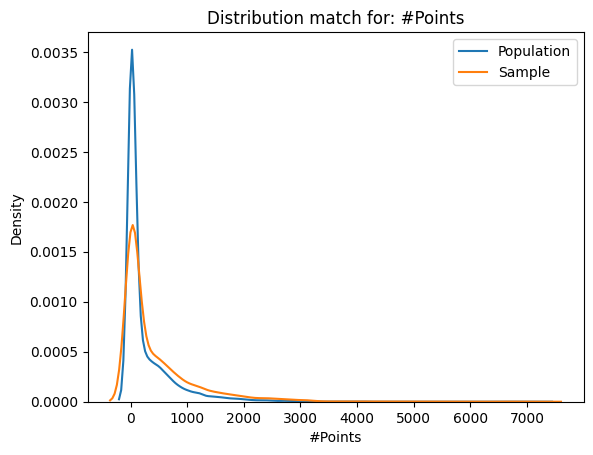

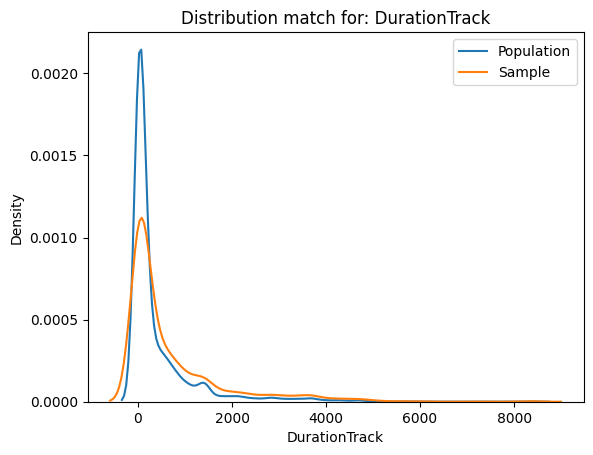

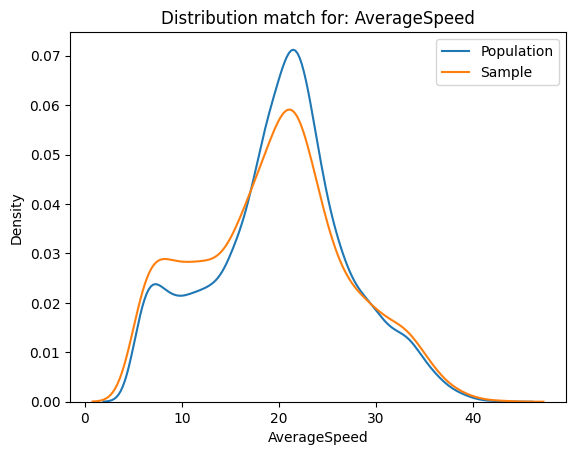

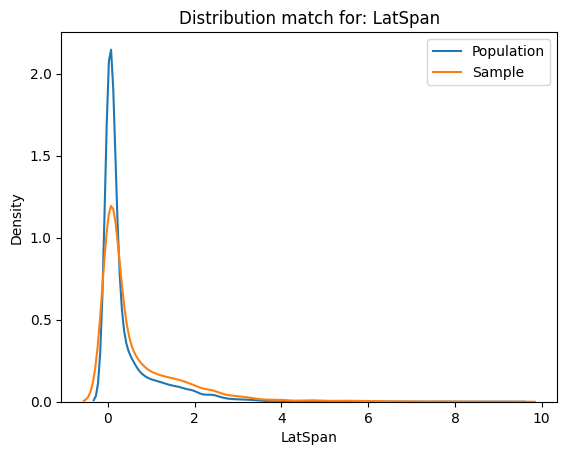

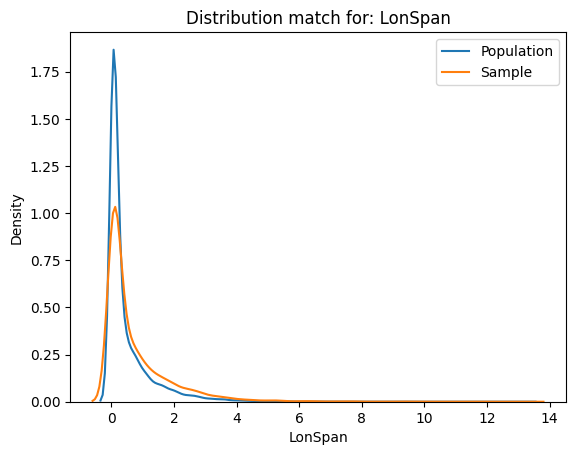

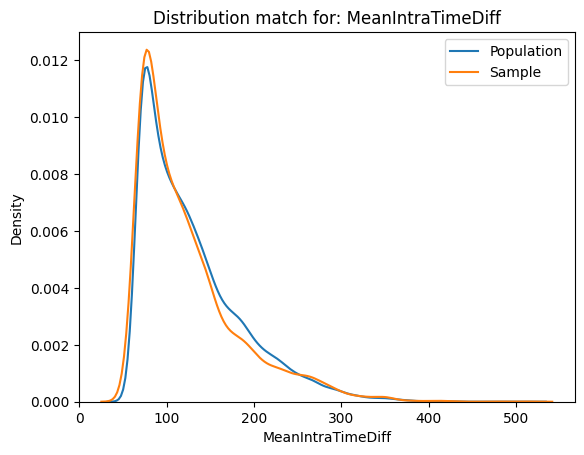

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in features:
    sns.kdeplot(AIS_charateristics[col], label="Population")
    sns.kdeplot(sampled[col], label="Sample")
    plt.title(f"Distribution match for: {col}")
    plt.legend()
    plt.show()


In [22]:
indices = sampled["ID"].unique()
df_continuous_routes.insert(0, "ID", df_continuous_routes.apply(lambda row: (row["MMSI"], row["TrackID"]), axis = 1))
df_subset = df_continuous_routes[df_continuous_routes["ID"].isin(indices)].copy()
df_subset.head(5)

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,TimeDiff,DistanceDiff,Speedkph,TrackID
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3


In [136]:
df_subset[df_subset['ID'] == (750000045, 16)]

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,TimeDiff,DistanceDiff,Speedkph,TrackID
4356536,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:39:05,16.47652,-66.47498,7.5,142.0,NaN,NaN,NaN,16
4356537,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:40:18,16.47514,-66.47302,7.4,141.0,73.0,0.259278,12.786300,16
4356538,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:44:51,16.46992,-66.46570,7.0,141.0,273.0,0.972703,12.826856,16
4356539,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:48:10,16.46626,-66.46049,6.4,140.0,199.0,0.688677,12.458478,16
4356540,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:53:58,16.45977,-66.45095,7.6,141.0,348.0,1.247281,12.902906,16
4356541,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:55:59,16.45758,-66.44760,6.7,138.0,121.0,0.432344,12.863116,16
4356542,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:58:19,16.45501,-66.44370,7.0,138.0,140.0,0.504614,12.975783,16
4356543,"(750000045, 16)",750000045,IMO6702284,2024-01-10 23:02:55,16.44986,-66.43640,6.4,139.0,276.0,0.966425,12.605543,16
4356544,"(750000045, 16)",750000045,IMO6702284,2024-01-10 23:04:12,16.44836,-66.43436,6.5,140.0,77.0,0.274134,12.816655,16


In [24]:
# genereer willekeurige tijdstippen met ~3 uur intervallen voor RF-signalen (Unseenlabs revisit time ≈ 3 uur)
# https://earth.esa.int/eogateway/missions/unseenlabs/description

def generate_random_start_time():
    """
    Generates a random start time between 00:00 and 02:59

    Returns:
        datetime: A random time representing the start time
    """
    start_hour = random.randint(0, 2)
    start_minute = random.randint(0, 59)
    start_time = datetime.strptime(f"{start_hour:02d}:{start_minute:02d}", "%H:%M")
    return start_time 

def generate_synthetic_RF_data():
    """
    Simulates RF revisit timestamps by starting from a randomly generated start time 
    and adding time intervals of approximately 3 to 4 hours

    Returns:
        list: Timestamps representing sythethic RF revisit times
    """
    random.seed(42)
    
    start_time = generate_random_start_time()
    times = [start_time]
    
    while True:
        minutes = random.randint(180, 240)
        seconds = random.randint(0,59)
        next_time = times[-1] + timedelta(minutes = minutes, seconds = seconds)
        
        if next_time.day != start_time.day:
            break
        
        times.append(next_time)
    return times

def generate_error_distance_and_bearing(
    timestamps, 
    mean_distance = 2000, 
    std_dev_distance = 100, 
    bearing_options = [0, 45, 90, 135, 180, 225, 270, 315]
    ):
    """
    Generates an error distance and bearing angle for each RF timestamp

    Args:
        timestamps (list): Simulated RF timestamps
        mean_distance (int): The average error distance in meters between the AIS point and the simulated RF signal, defaults to 2000
        std_dev_distance (int): Indicates how mcuh the generated distances can deviate from the average value. 
                                Given a mean of 2000 and a standard deviation of 100, most generated distances will fall roughly between 1900 and 2100 meters
        bearing_options (list): A list of possible direction (in degrees) that are added as deviations to the original course of the vessel, 
                                defaults to [0, 45, 90, 135, 180, 225, 270, 315]

    Returns:
        dict: timestamp: [error_distance, error_bearing]
    """
    return {
        timestamp: [
            round(np.random.normal(mean_distance, std_dev_distance), 6),
            random.choice(bearing_options)
        ] 
        for timestamp in timestamps
    }

def compute_coordinates(latitude, longitude, heading, error_distance, error_bearing):
    """
    Computes a new geographical coordinate from a base position using a error distance and bearing

    Args:
        latitude (float): Latitude of the reference point
        longitude (float): Longitude of the reference point
        heading (float): Direction of the ship at the reference point
        error_distance (float): Distance in meters to offset from the reference point
        error_bearing (float): Max error to add or subtract from the 'original' heading

    Returns:
        tuple: (latitude, longitude) of the simulated RF signal location
    """
    R = 6371000  

    noise = np.random.uniform(-error_bearing, error_bearing)
    bearing = math.radians((heading + noise) % 360)

    latitude, longitude = math.radians(latitude), math.radians(longitude)
    
    new_latitude = math.asin(
        math.sin(latitude) * math.cos(error_distance / R) + 
        math.cos(latitude) * math.sin(error_distance / R) * math.cos(bearing)
    )
    new_longitude = longitude + math.atan2(
        math.sin(bearing) * math.sin(error_distance / R) * math.cos(latitude),
        math.cos(error_distance / R) - math.sin(latitude) * math.sin(new_latitude)
    )

    new_latitude = math.degrees(new_latitude)
    new_longitude = math.degrees(new_longitude)
    
    return new_latitude, new_longitude

In [25]:
def get_RF_times_for_AIS_seq(RF_timestamps, AIS_seq, time_margin):
    """
    Selects RF timestamps that fall within the time window of an AIS route
    
    Args:
        timestamps (list): Simulated RF timestamps
        AIS_sequence (pd.DataFrame): AIS data
        time_margin (int): Times in minutes to expand the window before and after the AIS sequence

    Returns:
        list: RF timestamps that fall within the expanded AIS window
    """
    start_time = AIS_seq["BaseDateTime"].iloc[0] - timedelta(minutes = time_margin)
    end_time = AIS_seq["BaseDateTime"].iloc[-1] + timedelta(minutes = time_margin)
    unique_dates = AIS_seq['BaseDateTime'].dt.normalize().unique()
    
    return sorted([
        datetime.combine(pd.to_datetime(date).date(), RF_time.time())
        for date in unique_dates for RF_time in RF_timestamps
        if start_time <= datetime.combine(pd.to_datetime(date).date(), RF_time.time()) <= end_time
    ])
    
def generate_training_data(df, time_margin = 5):
    """
    Generates labeled training data by combining AIS trajectories with simulated RF signal observations
    
    For each AIS trajectory, and for every simulated RF timestamp that falls within its extended time window, the nearest AIS point is identified.
    A classification decision is then made based on the time and distance between the RF and AIS point.
        - If the probability of a match (based on time and distance) is higher than a standalone RF point, the RF signal is marked as a match ("M")
        - Otherwise, it is treated as an unmatched RF point ("RF")

    Args:
        df (pd.DataFrame): AIS data
        time_margin (int):  Number of minutes to extend the AIS route (before and after), defaults to 5

    Returns:
        pd.DataFrame: Labeled sequence data with the following columns:
            - UniqueRouteID
            - SubRouteID
            - MMSI
            - Timestamp
            - AIS_Timestamp 
            - RF_Timestamp
            - AIS (coordinates)
            - RF (coordinates)
            - State (one of: "M", "AIS", "RF", "begin", "end")
    """
    RF_revisit_timestamps = generate_synthetic_RF_data()
    train_data = []
    distance_differences = []
    
    for (id, mmsi, track_id), AIS_seq in df.groupby(["ID", "MMSI", "TrackID"]):
        AIS_seq["Matched"] = False
        
        RF_times = get_RF_times_for_AIS_seq(RF_revisit_timestamps, AIS_seq, time_margin)
        RF_erros = generate_error_distance_and_bearing(RF_times)
        
        for RF_datetime in RF_times:       
            # Find closest AIS information 
            closest_time_idx = (AIS_seq["BaseDateTime"] - RF_datetime).abs().idxmin()
            closest_AIS_time = AIS_seq.loc[closest_time_idx, "BaseDateTime"]
            closest_AIS_lat = AIS_seq.loc[closest_time_idx, "LAT"]
            closest_AIS_lon = AIS_seq.loc[closest_time_idx, "LON"]
            closest_AIS_heading = AIS_seq.loc[closest_time_idx, "Heading"]
            
            # Calculate the coordinates for RF signal
            distance, bearing = RF_erros[RF_datetime]
            synthetic_RF_lat, synthetic_RF_lon = compute_coordinates(closest_AIS_lat, closest_AIS_lon, closest_AIS_heading, distance, bearing)
            
            # Calculate the difference in distance and time between AIS and RF point
            distance_diff = haversine((closest_AIS_lat, closest_AIS_lon), (synthetic_RF_lat, synthetic_RF_lon))
            distance_differences.append(distance_diff)
            time_diff = abs((RF_datetime - closest_AIS_time).total_seconds())
            
            # Compute the likelihood that this RF signal is a match with an AIS point, or just a standalone RF signal
            prob_RF = AIS_RF_probability(time_diff, distance_diff)
            prob_match = match_probability(time_diff, distance_diff)
            
            if prob_match > prob_RF:
                state = "M"
                AIS_seq.at[closest_time_idx, "Matched"] = True 
            else:
                state = "RF"

            train_data.append({
                "ID": id,
                "TrackID": track_id,
                "MMSI": mmsi,
                "Timestamp": closest_AIS_time if state == "M" else RF_datetime,
                "AIS_Timestamp": closest_AIS_time if state == "M" else pd.NaT,
                "RF_Timestamp": RF_datetime,
                "AIS": [closest_AIS_lat, closest_AIS_lon] if state == "M" else None,
                "RF": [synthetic_RF_lat, synthetic_RF_lon],
                "State": state
            })
            
        for i, row in AIS_seq[~AIS_seq["Matched"]].iterrows():
            train_data.append({
                "ID": id,
                "TrackID": track_id,
                "MMSI": mmsi,
                "Timestamp": row["BaseDateTime"],
                "AIS_Timestamp": row["BaseDateTime"],
                "RF_Timestamp": pd.NaT,
                "AIS": [row["LAT"], row["LON"]],
                "RF": None,
                "State": "AIS"
            })
        
        time_begin = AIS_seq["BaseDateTime"].min() - timedelta(seconds = 1) 
        time_end = AIS_seq["BaseDateTime"].max() + timedelta(seconds = 1)
        
        for time, state in [(time_begin, "begin"), (time_end, "end")]:
            train_data.append({
                "ID": id,
                "TrackID": track_id,
                "MMSI": mmsi,
                "Timestamp": time,
                "AIS_Timestamp": pd.NaT,
                "RF_Timestamp": pd.NaT,
                "AIS": None,
                "RF": None,
                "State": state
            })  
    
    df_training = pd.DataFrame(train_data).sort_values(["ID", "Timestamp"])
    return df_training, distance_differences

In [26]:
df_train_set, list_distance_diffs = generate_training_data(df_subset)

In [35]:
save_path = "../../scripts/test_scripts/sample_set_5000.pkl" 
df_train_set.to_pickle(save_path)

In [138]:
df_train_set[df_train_set["ID"] == (750000045, 16)].tail(10)

,ID,TrackID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
2189889,"(750000045, 16)",16,750000045,2024-01-10 22:40:18,2024-01-10 22:40:18,NaT,"[16.47514, -66.47302]",None,AIS
2189890,"(750000045, 16)",16,750000045,2024-01-10 22:44:51,2024-01-10 22:44:51,NaT,"[16.46992, -66.4657]",None,AIS
2189891,"(750000045, 16)",16,750000045,2024-01-10 22:48:10,2024-01-10 22:48:10,NaT,"[16.46626, -66.46049]",None,AIS
2189892,"(750000045, 16)",16,750000045,2024-01-10 22:53:58,2024-01-10 22:53:58,NaT,"[16.45977, -66.45095]",None,AIS
2189893,"(750000045, 16)",16,750000045,2024-01-10 22:55:59,2024-01-10 22:55:59,NaT,"[16.45758, -66.4476]",None,AIS
2189894,"(750000045, 16)",16,750000045,2024-01-10 22:58:19,2024-01-10 22:58:19,NaT,"[16.45501, -66.4437]",None,AIS
2189895,"(750000045, 16)",16,750000045,2024-01-10 23:02:55,2024-01-10 23:02:55,NaT,"[16.44986, -66.4364]",None,AIS
2189896,"(750000045, 16)",16,750000045,2024-01-10 23:04:12,2024-01-10 23:04:12,NaT,"[16.44836, -66.43436]",None,AIS
2189898,"(750000045, 16)",16,750000045,2024-01-10 23:04:13,NaT,NaT,None,None,end
2189887,"(750000045, 16)",16,750000045,2024-01-10 23:08:37,NaT,2024-01-10 23:08:37,None,"[16.43711947566913, -66.41711039556493]",RF


In [132]:
t = df_train_set[df_train_set["RF"].notna()].copy()
t

,ID,TrackID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
0,"(205717000, 3)",3,205717000,2024-01-01 05:08:47,NaT,2024-01-01 05:08:47,None,"[46.904095122365135, -124.94317180657858]",RF
1,"(205717000, 3)",3,205717000,2024-01-01 08:26:02,NaT,2024-01-01 08:26:02,None,"[46.92349522222884, -124.12039587517351]",RF
2,"(205717000, 3)",3,205717000,2024-01-01 11:40:10,NaT,2024-01-01 11:40:10,None,"[46.91212287749819, -124.13361003252734]",RF
3,"(205717000, 3)",3,205717000,2024-01-01 15:27:16,NaT,2024-01-01 15:27:16,None,"[46.9246048226274, -124.09330848905059]",RF
384,"(205717000, 7)",7,205717000,2024-01-02 05:08:47,NaT,2024-01-02 05:08:47,None,"[46.93162093169572, -124.0964176090035]",RF
...,...,...,...,...,...,...,...,...,...
2188800,"(750000045, 1)",1,750000045,2024-01-07 08:26:02,NaT,2024-01-07 08:26:02,None,"[17.239780369333868, -66.38326175234393]",RF
2188801,"(750000045, 1)",1,750000045,2024-01-07 11:40:10,NaT,2024-01-07 11:40:10,None,"[17.29519097221895, -66.93675021369823]",RF
2188802,"(750000045, 1)",1,750000045,2024-01-07 15:27:16,NaT,2024-01-07 15:27:16,None,"[17.400141228752407, -67.52634105009477]",RF
2188803,"(750000045, 1)",1,750000045,2024-01-07 19:11:03,NaT,2024-01-07 19:11:03,None,"[17.637540552904365, -68.02829990507765]",RF


In [126]:
t[t["ID"] == (366904890, 0)].iloc[40]["RF_Timestamp"], t[t["ID"] == (366904890, 0)].iloc[40]["RF"]

(Timestamp('2024-01-06 19:11:03'), [42.97880759677565, -82.40680474084012])

In [125]:
haversine([42.97880759677565, -82.40680474084012], [47.01233, -85.3505])

504.6224396882723

In [124]:
df_train_set[df_train_set["ID"] == (316001701, 19)][3678:]

,ID,TrackID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
577443,"(316001701, 19)",19,316001701,2024-01-06 19:09:39,2024-01-06 19:09:39,NaT,"[47.0104, -85.34555]",None,AIS
577444,"(316001701, 19)",19,316001701,2024-01-06 19:10:50,2024-01-06 19:10:50,NaT,"[47.01233, -85.3505]",None,AIS
573786,"(316001701, 19)",19,316001701,2024-01-06 19:11:03,NaT,2024-01-06 19:11:03,None,"[47.0022047010513, -85.37153978901931]",RF
577445,"(316001701, 19)",19,316001701,2024-01-06 19:12:08,2024-01-06 19:12:08,NaT,"[47.01445, -85.35568]",None,AIS
577446,"(316001701, 19)",19,316001701,2024-01-06 19:13:09,2024-01-06 19:13:09,NaT,"[47.01612, -85.35967]",None,AIS
577447,"(316001701, 19)",19,316001701,2024-01-06 19:14:20,2024-01-06 19:14:20,NaT,"[47.01812, -85.36436]",None,AIS
577448,"(316001701, 19)",19,316001701,2024-01-06 19:15:30,2024-01-06 19:15:30,NaT,"[47.02009, -85.36899]",None,AIS
577449,"(316001701, 19)",19,316001701,2024-01-06 19:16:39,2024-01-06 19:16:39,NaT,"[47.02202, -85.3737]",None,AIS
577450,"(316001701, 19)",19,316001701,2024-01-06 19:17:50,2024-01-06 19:17:50,NaT,"[47.02383, -85.3785]",None,AIS
577451,"(316001701, 19)",19,316001701,2024-01-06 19:18:59,2024-01-06 19:18:59,NaT,"[47.02569, -85.38331]",None,AIS


In [129]:
import math
from datetime import timedelta

# Input: één AIS-track
track_key = (316001701, 19)
df_grouped = df_train_set[df_train_set["ID"] == track_key]

# Input: één RF-punt
rf_id = (366904890, 0)
rf_row = t[t["ID"] == rf_id].iloc[40]
RF_datetime = rf_row["RF_Timestamp"]
RF_coordinates = rf_row["RF"]  # Tuple (lat, lon)

# Instellingen
distance_threshold = 2.23  # km
time_marge = timedelta(minutes=10)

# Genereer metadata voor deze AIS-track
meta = {}
coords = [coord for coord in df_grouped["AIS"] if coord is not None]
if coords:
    lats = [c[0] for c in coords]
    lons = [c[1] for c in coords]

    min_lat = min(lats)
    max_lat = max(lats)
    min_lon = min(lons)
    max_lon = max(lons)

    # Marges op basis van afstand (in graden)
    lat_margin = distance_threshold / 111  # 1 graad ≈ 111 km
    lon_margin_min = distance_threshold / (111 * math.cos(math.radians(min_lat)))
    lon_margin_max = distance_threshold / (111 * math.cos(math.radians(max_lat)))

    # Metadata opslaan
    meta[track_key] = {
        "data": df_grouped,
        "coords": coords,
        "min_lat": min_lat - lat_margin,
        "max_lat": max_lat + lat_margin,
        "min_lon": min_lon - lon_margin_min,
        "max_lon": max_lon + lon_margin_max,
        "min_time": df_grouped["AIS_Timestamp"].min() - time_marge,
        "max_time": df_grouped["AIS_Timestamp"].max() + time_marge
    }

# === Check alle drie de voorwaarden ===
if track_key in meta:
    info = meta[track_key]

    time_check = info["min_time"] <= RF_datetime <= info["max_time"]
    bbox_check = (
        info["min_lat"] <= RF_coordinates[0] <= info["max_lat"] and
        info["min_lon"] <= RF_coordinates[1] <= info["max_lon"]
    )
    distance_check = any(
        haversine(RF_coordinates, coord) <= distance_threshold
        for coord in info["coords"]
    )

    if time_check and bbox_check and distance_check:
        print(f"✅ JA — match gevonden binnen alle marges. Afstand binnen threshold. {distance_check}")
    else:
        print("❌ NEE — één of meer checks zijn gefaald.")
else:
    print("⚠️ track_key niet gevonden in meta.")


✅ JA — match gevonden binnen alle marges. Afstand binnen threshold. True


In [99]:
forward_results = pd.read_pickle("../../scripts/test_scripts/alignments_df.pkl")

In [100]:
forward_results[forward_results["IsTrueMatch"] == True]

,RFSignalID,RFTrackID,AISTrackID,ForwardScore,NormalizedForwardScore,IsTrueMatch
0,1,"(205717000, 3)","(205717000, 3)",-16.953044,-0.044849,True
1,2,"(205717000, 3)","(205717000, 3)",-16.620944,-0.043971,True
2,3,"(205717000, 3)","(205717000, 3)",-15.899161,-0.042061,True
3,4,"(205717000, 3)","(205717000, 3)",-15.678727,-0.041478,True
4,1,"(205717000, 7)","(205717000, 7)",-11.101144,-0.055785,True
...,...,...,...,...,...,...
43788,3,"(750000045, 1)","(750000045, 1)",-33.892722,-0.031616,True
43789,4,"(750000045, 1)","(750000045, 1)",-34.034110,-0.031748,True
43790,5,"(750000045, 1)","(750000045, 1)",-33.725891,-0.031461,True
43791,6,"(750000045, 1)","(750000045, 1)",-34.482388,-0.032166,True


In [106]:
# Groepeer op RFTrackID en tel hoeveel AISTrackID's er per RFTrackID zijn
counts_per_rftrack = forward_results.groupby(["RFSignalID", "RFTrackID"])["AISTrackID"].nunique()

# Bereken het gemiddelde aantal gekoppelde AIS-tracks per RF-track
average_matches = counts_per_rftrack.mean()

print(f"Gemiddeld aantal AIS-tracks per RF-track: {average_matches:.2f}")

Gemiddeld aantal AIS-tracks per RF-track: 2.56


In [102]:
best_predictions = forward_results.loc[forward_results.groupby(["RFSignalID", "RFTrackID"])["NormalizedForwardScore"].idxmax()]
best_predictions[best_predictions["IsTrueMatch"] == False]

,RFSignalID,RFTrackID,AISTrackID,ForwardScore,NormalizedForwardScore,IsTrueMatch
16,1,"(209087000, 10)","(351567000, 19)",-33.793927,-0.031465,False
809,1,"(210499000, 15)","(368270390, 0)",-129.616274,-0.029272,False
1217,1,"(215228000, 7)","(636017316, 12)",-36.448784,-0.031126,False
1443,1,"(215765000, 2)","(636019582, 6)",-49.652530,-0.029207,False
2383,1,"(235010180, 19)","(477909100, 31)",-27.748794,-0.035484,False
...,...,...,...,...,...,...
41776,24,"(636022464, 30)","(256524000, 97)",-70.498425,-0.028053,False
33792,25,"(538009326, 1)","(477950300, 3)",-61.712304,-0.028744,False
41785,25,"(636022464, 30)","(256524000, 97)",-70.228260,-0.027946,False
43546,31,"(636093060, 4)","(368270390, 0)",-121.433221,-0.027424,False


In [103]:
best_predictions[best_predictions["IsTrueMatch"] == True]

,RFSignalID,RFTrackID,AISTrackID,ForwardScore,NormalizedForwardScore,IsTrueMatch
0,1,"(205717000, 3)","(205717000, 3)",-16.953044,-0.044849,True
4,1,"(205717000, 7)","(205717000, 7)",-11.101144,-0.055785,True
6,1,"(205717000, 82)","(205717000, 82)",-24.772183,-0.035138,True
11,1,"(209017000, 19)","(209017000, 19)",-5.840272,-0.834325,True
12,1,"(209017000, 23)","(209017000, 23)",-6.291301,-0.190645,True
...,...,...,...,...,...,...
18556,41,"(366904890, 0)","(366904890, 0)",-176.864184,-0.026688,True
19864,41,"(366938770, 0)","(366938770, 0)",-148.204531,-0.026728,True
20025,41,"(366938780, 0)","(366938780, 0)",-192.577800,-0.026625,True
20868,41,"(367121010, 0)","(367121010, 0)",-186.983258,-0.026496,True


In [104]:
TP = 15388
FP = 1693
precision = TP / (TP + FP)
print(f"Precision: {precision:.4f}")

Precision: 0.9009


In [93]:
import math

RF_coordinates = [46.9246048226274, -124.09330848905059]
distance_threshold = 2.23  # in kilometers

min_lat = min(lats)
max_lat = max(lats)
min_lon = min(lons)
max_lon = max(lons)

# Afstanden omgerekend naar graden
lat_margin = distance_threshold / 111
lon_margin_min = distance_threshold / (111 * math.cos(math.radians(min_lat)))
lon_margin_max = distance_threshold / (111 * math.cos(math.radians(max_lat)))

# Voorwaarde: binnen bounding box + marge
if not (
    min_lat - lat_margin <= RF_coordinates[0] <= max_lat + lat_margin and
    min_lon - lon_margin_min <= RF_coordinates[1] <= max_lon + lon_margin_max
):
    print("hoort der niet bij")
         

In [90]:
haversine([46.92174, -124.11781], [46.9246048226274, -124.09330848905059])

1.8878097585511742

In [87]:
min(lons)-(distance_threshold/(111*math.cos(min_lat)))

-125.37292303192278

In [91]:
max(lons)

-124.11041

In [88]:
max(lons)+(distance_threshold/(111*math.cos(max(lats))))

-124.15848776332975

In [ ]:
df_train_set[df_train_set["ID"] == (205717000, 3)]

In [40]:
forward_results = pd.read_pickle("../../scripts/test_scripts/alignments_df.pkl")

In [51]:
forward_results[forward_results["RFTrackID"] == (205717000, 3)]

,RFSignalID,RFTrackID,AISTrackID,ForwardScore,NormalizedForwardScore,IsTrueMatch
0,1,"(205717000, 3)","(205717000, 3)",-16.953044,-0.044849,True
1,2,"(205717000, 3)","(205717000, 3)",-16.620944,-0.043971,True
2,3,"(205717000, 3)","(205717000, 3)",-15.899161,-0.042061,True


In [43]:
forward_results[forward_results["IsTrueMatch"] == True]

,RFSignalID,RFTrackID,AISTrackID,ForwardScore,NormalizedForwardScore,IsTrueMatch
0,1,"(205717000, 3)","(205717000, 3)",-16.953044,-0.044849,True
1,2,"(205717000, 3)","(205717000, 3)",-16.620944,-0.043971,True
2,3,"(205717000, 3)","(205717000, 3)",-15.899161,-0.042061,True
3,1,"(205717000, 7)","(205717000, 7)",-11.101144,-0.055785,True
4,1,"(205717000, 82)","(205717000, 82)",-24.772183,-0.035138,True
...,...,...,...,...,...,...
36855,2,"(750000045, 1)","(750000045, 1)",-33.800824,-0.031531,True
36856,3,"(750000045, 1)","(750000045, 1)",-33.892722,-0.031616,True
36857,4,"(750000045, 1)","(750000045, 1)",-34.034110,-0.031748,True
36858,5,"(750000045, 1)","(750000045, 1)",-33.725891,-0.031461,True


In [87]:
forward_results.sort_values(["RFRouteID", "RFSignalID"])

,UniqueRouteID,SubRouteID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
382,1396,3,205717000,2024-01-01 03:40:23,NaT,NaT,None,None,begin
4,1396,3,205717000,2024-01-01 03:40:24,2024-01-01 03:40:24,NaT,"[46.89339, -125.42151]",None,AIS
5,1396,3,205717000,2024-01-01 03:44:15,2024-01-01 03:44:15,NaT,"[46.89344, -125.39996]",None,AIS
6,1396,3,205717000,2024-01-01 03:45:33,2024-01-01 03:45:33,NaT,"[46.8935, -125.39274]",None,AIS
7,1396,3,205717000,2024-01-01 03:46:39,2024-01-01 03:46:39,NaT,"[46.89348, -125.38572]",None,AIS
...,...,...,...,...,...,...,...,...,...
4422281,7321,19,750000076,2024-01-05 03:55:30,2024-01-05 03:55:30,NaT,"[16.36872, -65.5559]",None,AIS
4422282,7321,19,750000076,2024-01-05 03:58:10,2024-01-05 03:58:10,NaT,"[16.36608, -65.55114]",None,AIS
4422283,7321,19,750000076,2024-01-05 04:04:39,2024-01-05 04:04:39,NaT,"[16.35969, -65.53966]",None,AIS
4422284,7321,19,750000076,2024-01-05 04:07:50,2024-01-05 04:07:50,NaT,"[16.35669, -65.53414]",None,AIS


In [ ]:
# alles hierboven is belangrijk 

In [60]:
df_train_set[df_train_set["UniqueRouteID"] == 1][10:20]

,UniqueRouteID,SubRouteID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
5473,1,0,209136000,2024-01-08 22:56:24,2024-01-08 22:56:24,NaT,"[28.53924, -89.69059]",None,AIS
5474,1,0,209136000,2024-01-08 22:57:35,2024-01-08 22:57:35,NaT,"[28.54235, -89.68775]",None,AIS
5475,1,0,209136000,2024-01-08 22:59:35,2024-01-08 22:59:35,NaT,"[28.54758, -89.68319]",None,AIS
5476,1,0,209136000,2024-01-08 23:00:25,2024-01-08 23:00:25,NaT,"[28.54966, -89.68132]",None,AIS
5477,1,0,209136000,2024-01-08 23:02:25,2024-01-08 23:02:25,NaT,"[28.55486, -89.67693]",None,AIS
5478,1,0,209136000,2024-01-08 23:07:44,2024-01-08 23:07:44,NaT,"[28.56874, -89.66455]",None,AIS
5450,1,0,209136000,2024-01-08 23:08:37,NaT,2024-01-08 23:08:37,None,"[28.54970914486886, -89.66553563299703]",RF
5479,1,0,209136000,2024-01-08 23:12:55,2024-01-08 23:12:55,NaT,"[28.58203, -89.65335]",None,AIS
5480,1,0,209136000,2024-01-08 23:14:14,2024-01-08 23:14:14,NaT,"[28.58532, -89.65054]",None,AIS
5481,1,0,209136000,2024-01-08 23:15:45,2024-01-08 23:15:45,NaT,"[28.58914, -89.64729]",None,AIS


In [105]:
max(list_distance_diffs), np.percentile(list_distance_diffs, 100)

(2.430230409772223, np.float64(2.430230409772223))

In [86]:
time_marge = timedelta(minutes = 10)
distance_threshold = np.percentile(list_distance_diffs, 99)

df_RF = df_train_set[df_train_set["RF"].notna()].copy()
df_RF["RFSignalID"] = df_RF.groupby("UniqueRouteID").cumcount() + 1
RF_signal = df_RF[(df_RF["UniqueRouteID"] == 1) & (df_RF["RFSignalID"] == 1)].iloc[0]

RF_datetime = RF_signal["RF_Timestamp"]
RF_coordinates = RF_signal["RF"]
RF_seq_id = RF_signal["UniqueRouteID"]
RF_signal_id = RF_signal["RFSignalID"]

print(RF_coordinates)

# RF_signal_within_radius = any(haversine(RF_coordinates, coord) <= distance_threshold for coord in AIS_coordinates)

t = df_train_set[df_train_set["UniqueRouteID"] == 1]
AIS_coordinates = [coord for coord in t["AIS"] if coord is not None]
RF_signal_within_radius = any(haversine(RF_coordinates, coord) <= distance_threshold for coord in AIS_coordinates)

# Check if RF signal within time bounds
min_AIS_datetime = t["AIS_Timestamp"].min() - time_marge
max_AIS_datetime = t["AIS_Timestamp"].max() + time_marge
RF_signal_within_time = min_AIS_datetime <= RF_datetime <= max_AIS_datetime

print(RF_signal_within_radius, RF_signal_within_time)

[28.54970914486886, -89.66553563299703]
True True


In [79]:
haversine([28.45622, -89.76579], [28.54970914486886, -89.66553563299703])

14.284269067590678

In [63]:
t

,UniqueRouteID,SubRouteID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
5473,1,0,209136000,2024-01-08 22:56:24,2024-01-08 22:56:24,NaT,"[28.53924, -89.69059]",None,AIS
5474,1,0,209136000,2024-01-08 22:57:35,2024-01-08 22:57:35,NaT,"[28.54235, -89.68775]",None,AIS
5475,1,0,209136000,2024-01-08 22:59:35,2024-01-08 22:59:35,NaT,"[28.54758, -89.68319]",None,AIS
5476,1,0,209136000,2024-01-08 23:00:25,2024-01-08 23:00:25,NaT,"[28.54966, -89.68132]",None,AIS
5477,1,0,209136000,2024-01-08 23:02:25,2024-01-08 23:02:25,NaT,"[28.55486, -89.67693]",None,AIS
5478,1,0,209136000,2024-01-08 23:07:44,2024-01-08 23:07:44,NaT,"[28.56874, -89.66455]",None,AIS
5450,1,0,209136000,2024-01-08 23:08:37,NaT,2024-01-08 23:08:37,None,"[28.54970914486886, -89.66553563299703]",RF
5479,1,0,209136000,2024-01-08 23:12:55,2024-01-08 23:12:55,NaT,"[28.58203, -89.65335]",None,AIS
5480,1,0,209136000,2024-01-08 23:14:14,2024-01-08 23:14:14,NaT,"[28.58532, -89.65054]",None,AIS
5481,1,0,209136000,2024-01-08 23:15:45,2024-01-08 23:15:45,NaT,"[28.58914, -89.64729]",None,AIS


In [53]:
# filter train data op waar RF-data aanwezig is
df_RF = df_train_set[df_train_set["RF"].notna()].copy()
df_RF["RFSignalID"] = df_RF.groupby("UniqueRouteID").cumcount() + 1

df_RF.sort_values(["UniqueRouteID", "RFSignalID"])

,UniqueRouteID,SubRouteID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State,RFSignalID
5450,1,0,209136000,2024-01-08 23:08:37,NaT,2024-01-08 23:08:37,None,"[28.54970914486886, -89.66553563299703]",RF,1
5451,1,0,209136000,2024-01-09 02:07:00,NaT,2024-01-09 02:07:00,None,"[28.880212839110825, -89.39827545135141]",RF,2
5452,1,0,209136000,2024-01-09 05:08:47,NaT,2024-01-09 05:08:47,None,"[29.21337692363925, -89.30115690642349]",RF,3
5453,1,0,209136000,2024-01-09 08:26:02,NaT,2024-01-09 08:26:02,None,"[29.244333455170963, -89.28292462563665]",RF,4
5454,1,0,209136000,2024-01-09 11:39:21,2024-01-09 11:39:21,2024-01-09 11:40:10,"[29.22886, -89.29829]","[29.242896828683154, -89.308218026839]",M,5
...,...,...,...,...,...,...,...,...,...,...
2278081,16717,539,368099310,2024-01-29 05:08:47,NaT,2024-01-29 05:08:47,None,"[28.574595758570528, -89.15385472830413]",RF,3
1782951,16720,550,366014000,2024-01-25 05:08:47,NaT,2024-01-25 05:08:47,None,"[28.687357525668737, -88.28068633125442]",RF,1
1782986,16723,556,366014000,2024-01-25 08:26:02,NaT,2024-01-25 08:26:02,None,"[28.763690241954983, -88.40775444213239]",RF,1
1782987,16723,556,366014000,2024-01-25 11:40:10,NaT,2024-01-25 11:40:10,None,"[28.736537629299672, -88.36200190201188]",RF,2


In [37]:
# run forward algorithm:
states = [ BeginState(), AISState(), RFState(), MState(), EndState()]
forward_model = PHMM_forward(states, EndState())

# filter train data op waar RF-data aanwezig is
df_RF = df_train_set[df_train_set["RF"].notna()].copy()
df_RF["RFSignalID"] = df_RF.groupby("UniqueRouteID").cumcount() + 1

distance_threshold = np.percentile(list_distance_diffs, 99)
time_marge = timedelta(minutes = 10)
alignment_results = []

for _, RF_signal in df_RF.iterrows():
    RF_datetime = RF_signal["RF_Timestamp"]
    RF_coordinates = RF_signal["RF"]
    RF_seq_id = RF_signal["UniqueRouteID"]
    RF_signal_id = RF_signal["RFSignalID"]
        
    for AIS_seq_id, AIS_seq in df_train_set.groupby("UniqueRouteID"):        
        # Check if RF signal within distance threshold
        AIS_coordinates = [coord for coord in AIS_seq["AIS"] if coord is not None]
        RF_signal_within_radius = any(haversine(RF_coordinates, coord) <= distance_threshold for coord in AIS_coordinates)
        
        # Check if RF signal within time bounds
        min_AIS_datetime = AIS_seq["AIS_Timestamp"].min() - time_marge
        max_AIS_datetime = AIS_seq["AIS_Timestamp"].max() + time_marge
        RF_signal_within_time = min_AIS_datetime <= RF_datetime <= max_AIS_datetime

        if RF_signal_within_radius and RF_signal_within_time:
            # Make sequences 
            AIS_seq = [(datetime, coordinates)
                    for datetime, coordinates in zip(AIS_seq["AIS_Timestamp"], AIS_seq["AIS"])
                    if pd.notna(datetime) and coordinates is not None]
            RF_seq = [(RF_datetime, RF_coordinates)]
            
            is_true_match = RF_seq_id == AIS_seq_id
            
            alignment_results.append({
                "RFSignalID": RF_signal_id,
                "RFRouteID": RF_seq_id,
                "AISRouteID": AIS_seq_id,
                "IsTrueMatch": is_true_match
            })

KeyboardInterrupt: 

In [38]:
alignment_results

[{'RFSignalID': 1, 'RFRouteID': 1396, 'AISRouteID': 1396, 'IsTrueMatch': True},
 {'RFSignalID': 2, 'RFRouteID': 1396, 'AISRouteID': 1396, 'IsTrueMatch': True}]

In [22]:
distance_threshold.round(2)

np.float64(2.23)

In [20]:
alignment_results

[{'RFSignalID': 1,
  'RFRouteID': 1396,
  'AISRouteID': 1396,
  'ForwardScore': np.float64(-15.9000292048),
  'NormalizedForwardScore': np.float64(-0.042063569324867725),
  'IsTrueMatch': True}]

In [ ]:
# stap 2, preselectie van mogelijke AIS sequenties op basis van:
    # tijdsvenster (+- 5 minuten)
    # ruimtelijke afstand (2 km van een van de AIS punten)

# stap 3, forward algorithme draaien op:
    # elke combinatie van het RF signaal + kandidaat AIS sequentie
    # sla deze allemaal op in een dataframe + ook de adjusted forward score (forward / len(AIS_seq))
    
candidates = []
distance_threshold = 2
time_marge = pd.Timedelta(minutes = 10) # deze 10 minuten 

for _, RF_signal in RF_signals_sample.iterrows():
    RF_datetime = RF_signal["RF_Timestamp"]
    RF_coordinates = RF_signal["RF"]
    RF_seq_id = RF_signal["UniqueRouteID"]
    RF_signal_id = RF_signal["RF_index_in_route"]
    
    best_score = -np.inf
    best_candidate = None
    best_adjusted_score = None
    
    for AIS_seq_id, AIS_seq in PHMM_df.groupby("UniqueRouteID"):
        # Check if RF signal within distance threshold
        AIS_coordinates = [coord for coord in AIS_seq["AIS"] if coord is not None]
        RF_signal_within_radius = any(haversine(RF_coordinates, coord) <= distance_threshold for coord in AIS_coordinates)
        
        # Check if RF signal within time bounds
        min_AIS_datetime = AIS_seq["AIS_Timestamp"].min() - time_marge
        max_AIS_datetime = AIS_seq["AIS_Timestamp"].max() + time_marge
        RF_signal_within_time = min_AIS_datetime <= RF_datetime <= max_AIS_datetime

        if RF_signal_within_radius and RF_signal_within_time:
            # Make sequenties 
            AIS_seq = [(datetime, coordinates)
                    for datetime, coordinates in zip(AIS_seq["AIS_Timestamp"], AIS_seq["AIS"])
                    if pd.notna(datetime) and coordinates is not None]
            RF_seq = [(RF_datetime, RF_coordinates)]
        
            # Forward algorithm 
            forward_score = forward_model.forward(AIS_seq, RF_seq)
            adjusted_forward_score = forward_score/len(AIS_seq)
            
            is_true_match = RF_seq_id == AIS_seq_id
            
            candidates.append({
                "RF_signal_ID": RF_signal_id,
                "RF_seq_id": RF_seq_id,
                "AIS_seq_ID": AIS_seq_id,
                "Forward_score": forward_score,
                "Adjusted_Forward_score": adjusted_forward_score, 
                "y_true": is_true_match
            })

In [21]:
from scripts.PHMM.viterbi_algorithm.states import *
from scripts.PHMM.viterbi_algorithm.viterbi import *
from scripts.PHMM.distributions.AIS_RF_distribution import *
import pandas as pd

begin = BeginState()
AIS = AISState()
RF = RFState()
M = MState()
end = EndState()

states = [begin, AIS, RF, M, end]
viterbi_model = PHMM(states, end)

In [134]:
sequence = df_train_set[df_train_set['UniqueRouteID'] == 1]

AIS_sequence = [(time, coord) for time, coord in zip(sequence["AIS_Timestamp"], sequence["AIS"]) 
                if pd.notna(time) and coord is not None]

RF_sequence = [(time, coord) for time, coord in zip(sequence["RF_Timestamp"], sequence["RF"]) 
               if pd.notna(time) and coord is not None]

KeyError: 'UniqueRouteID'

In [133]:
AIS_sequence

NameError: name 'AIS_sequence' is not defined

In [23]:
path, probability, log_probs = viterbi_model.viterbi(AIS_sequence, RF_sequence)

In [24]:
RF_M_indexes_pred_path = [(i, state) for i, state in enumerate(path) if state in {"RF", "M"}]
RF_M_indexes_real_path = [(i, state) for i, state in enumerate(sequence["State"]) if state in {"RF", "M"}]
print(f"The indexes of RF and/or M of predicted path are: {RF_M_indexes_pred_path}, \
      \nThe indexes of RF and/or M of the real path are: {RF_M_indexes_real_path}")

The indexes of RF and/or M of predicted path are: [(16, 'RF'), (159, 'RF'), (313, 'RF'), (379, 'M'), (441, 'RF'), (548, 'RF'), (748, 'RF'), (897, 'M'), (957, 'RF'), (1017, 'M'), (1081, 'RF'), (1146, 'RF'), (1219, 'M'), (1291, 'RF')],       
The indexes of RF and/or M of the real path are: [(15, 'M'), (158, 'RF'), (312, 'RF'), (379, 'M'), (439, 'M'), (546, 'RF'), (746, 'RF'), (895, 'M'), (955, 'RF'), (1015, 'M'), (1079, 'RF'), (1144, 'RF'), (1218, 'M'), (1289, 'RF')]


In [140]:
sequence2 = df_train_set[df_train_set['UniqueRouteID'] == 190]

AIS_sequence2 = [(time, coord) for time, coord in zip(sequence2["AIS_Timestamp"], sequence2["AIS"]) 
                if pd.notna(time) and coord is not None]

RF_sequence2 = [(time, coord) for time, coord in zip(sequence2["RF_Timestamp"], sequence2["RF"]) 
               if pd.notna(time) and coord is not None]

KeyError: 'UniqueRouteID'

In [139]:
AIS_sequence2

NameError: name 'AIS_sequence2' is not defined

In [34]:
sequence2

,UniqueRouteID,SubRouteID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
1795958,190,0,366893910,2024-01-01 00:01:28,NaT,NaT,None,None,begin
1793962,190,0,366893910,2024-01-01 00:01:29,2024-01-01 00:01:29,NaT,"[43.01629, -87.9017]",None,AIS
1793963,190,0,366893910,2024-01-01 00:04:32,2024-01-01 00:04:32,NaT,"[43.0163, -87.90171]",None,AIS
1793964,190,0,366893910,2024-01-01 00:07:30,2024-01-01 00:07:30,NaT,"[43.01631, -87.90171]",None,AIS
1793965,190,0,366893910,2024-01-01 00:10:31,2024-01-01 00:10:31,NaT,"[43.0163, -87.90169]",None,AIS
...,...,...,...,...,...,...,...,...,...
1795954,190,0,366893910,2024-01-02 23:39:55,2024-01-02 23:39:55,NaT,"[44.5061, -88.02284]",None,AIS
1795955,190,0,366893910,2024-01-02 23:41:05,2024-01-02 23:41:05,NaT,"[44.50697, -88.02252]",None,AIS
1795956,190,0,366893910,2024-01-02 23:42:16,2024-01-02 23:42:16,NaT,"[44.50781, -88.0221]",None,AIS
1795957,190,0,366893910,2024-01-02 23:43:25,2024-01-02 23:43:25,NaT,"[44.50858, -88.02165]",None,AIS


In [35]:
path2, probability2, log_probs2 = viterbi_model.viterbi(AIS_sequence2, RF_sequence2)

In [36]:
RF_M_indexes_pred_path2 = [(i, state) for i, state in enumerate(path2) if state in {"RF", "M"}]
RF_M_indexes_real_path2 = [(i, state) for i, state in enumerate(sequence2["State"]) if state in {"RF", "M"}]
print(f"The indexes of RF and/or M of predicted path are: {RF_M_indexes_pred_path2}, \
      \nThe indexes of RF and/or M of the real path are: {RF_M_indexes_real_path2}")

The indexes of RF and/or M of predicted path are: [(39, 'RF'), (101, 'RF'), (165, 'RF'), (228, 'RF'), (331, 'RF'), (527, 'RF'), (735, 'RF'), (892, 'RF'), (1052, 'RF'), (1223, 'RF'), (1385, 'RF'), (1581, 'RF'), (1776, 'RF'), (1980, 'RF')],       
The indexes of RF and/or M of the real path are: [(39, 'RF'), (101, 'RF'), (165, 'RF'), (228, 'RF'), (331, 'RF'), (527, 'RF'), (735, 'RF'), (892, 'RF'), (1052, 'RF'), (1223, 'RF'), (1385, 'RF'), (1581, 'RF'), (1776, 'RF'), (1980, 'RF')]


In [ ]:
def create_prediction_dataframe(path, AIS_sequence, RF_sequence):    
    results = []
    RF_M_counter = 0 
    AIS_idx = -1
 
    for state in path:
        if state == "AIS":
            AIS_idx += 1
            results.append({
                "State_pred": state,
                "AIS_Timestamp_pred": AIS_sequence[AIS_idx][0],
                "RF_Timestamp_pred": pd.NaT,
            })
        elif state == "RF":
            results.append({
                "State_pred": state,
                "AIS_Timestamp_pred": pd.NaT,
                "RF_Timestamp_pred": RF_sequence[RF_M_counter][0],
            })
            RF_M_counter += 1
        elif state == "M":
            AIS_idx += 1
            results.append({
                "State_pred": state,
                "AIS_Timestamp_pred": AIS_sequence[AIS_idx][0],
                "RF_Timestamp_pred": RF_sequence[RF_M_counter][0],
            })
            RF_M_counter += 1

    return pd.DataFrame(results)    

In [ ]:
def merge_predictions_and_actuals(df_pred, df_actual):
    df_pred = df_pred.copy()
    df_actual = df_actual.copy()

    # Filter begin/end uit actuals
    df_actual = df_actual[~df_actual['State'].isin(['begin', 'end'])][["State", "AIS_Timestamp", "RF_Timestamp"]]

    # Maak merge_keys
    df_pred['merge_key'] = df_pred['AIS_Timestamp_pred'].fillna(df_pred['RF_Timestamp_pred'])
    df_actual['merge_key'] = df_actual['AIS_Timestamp'].fillna(df_actual['RF_Timestamp'])

    # Merge
    merged = pd.merge(
        df_pred,
        df_actual,
        on='merge_key',
        how='outer',
        suffixes=('_pred', '_actual')
    ).drop(columns=['merge_key'])

    # Sorteren
    merged['sort_key'] = merged['AIS_Timestamp_pred'].fillna(merged['RF_Timestamp_pred'])
    merged = merged.sort_values('sort_key').drop(columns='sort_key')
    merged = merged.reset_index(drop=True)

    # Vul ontbrekende voorspellingen aan met '-'
    missing_pred = merged['State_pred'].isna()
    pred_cols = ['State_pred', 'AIS_Timestamp_pred', 'RF_Timestamp_pred']
    merged.loc[missing_pred, pred_cols] = '-'

    # Vul ontbrekende actuele data aan met '-'
    missing_actual = merged['State'].isna()
    actual_cols = ['State', 'AIS_Timestamp', 'RF_Timestamp']
    merged.loc[missing_actual, actual_cols] = '-'

    # Scheidingskolom
    merged.insert(3, "", "|")

    # Voeg indexkolommen toe (start met alles op NaN)
    merged.insert(0, "index_pred", "-")
    merged.insert(5, "index", "-")

    # Tel bij via counters
    pred_counter = 1
    actual_counter = 1

    for i, row in merged.iterrows():
        if row['State_pred'] != '-':
            merged.at[i, 'index_pred'] = pred_counter
            pred_counter += 1
        if row['State'] != '-':
            merged.at[i, 'index'] = actual_counter
            actual_counter += 1

    # Begin- en eindrijen toevoegen
    begin_row = {
        'index_pred': 0,
        'State_pred': 'begin',
        'AIS_Timestamp_pred': pd.NaT,
        'RF_Timestamp_pred': pd.NaT,
        '': '|',
        'index': 0,
        'State': 'begin',
        'AIS_Timestamp': pd.NaT,
        'RF_Timestamp': pd.NaT,  
    }

    end_row = {
        'index_pred': pred_counter,
        'State_pred': 'end',
        'AIS_Timestamp_pred': pd.NaT,
        'RF_Timestamp_pred': pd.NaT,
        '': '|',
        'index': actual_counter,
        'State': 'end',
        'AIS_Timestamp': pd.NaT,
        'RF_Timestamp': pd.NaT,
    }

    merged = pd.concat(
        [pd.DataFrame([begin_row]), merged, pd.DataFrame([end_row])],
        ignore_index=True
    )

    return merged


In [ ]:
df_pred = create_prediction_dataframe(path2, AIS_sequence2, RF_sequence2)

merge_predictions_and_actuals(df_pred, sequence2)

,index_pred,State_pred,AIS_Timestamp_pred,RF_Timestamp_pred,,index,State,AIS_Timestamp,RF_Timestamp
0,0,begin,NaN,NaN,|,0,begin,NaN,NaN
1,1,AIS,2024-01-01 02:32:02,NaT,|,1,AIS,2024-01-01 02:32:02,NaT
2,2,AIS,2024-01-01 02:38:32,NaT,|,2,AIS,2024-01-01 02:38:32,NaT
3,3,AIS,2024-01-01 02:42:02,NaT,|,3,AIS,2024-01-01 02:42:02,NaT
4,4,AIS,2024-01-01 02:43:52,NaT,|,4,AIS,2024-01-01 02:43:52,NaT
...,...,...,...,...,...,...,...,...,...
1117,1117,AIS,2024-01-02 00:28:53,NaT,|,1117,AIS,2024-01-02 00:28:53,NaT
1118,1118,AIS,2024-01-02 00:31:53,NaT,|,1118,AIS,2024-01-02 00:31:53,NaT
1119,1119,AIS,2024-01-02 00:38:32,NaT,|,1119,AIS,2024-01-02 00:38:32,NaT
1120,1120,AIS,2024-01-02 00:44:21,NaT,|,1120,AIS,2024-01-02 00:44:21,NaT


In [ ]:
from scripts.PHMM.viterbi_algorithm.forward import *

begin = BeginState()
AIS = AISState()
RF = RFState()
M = MState()
end = EndState()

states = [begin, AIS, RF, M, end]
forward_model = PHMM(states, end)

In [ ]:
# stap 1, verkrijg alleen RF data
RF_signals_df = PHMM_df[PHMM_df["RF"].notna()].copy()
RF_signals_df["RF_index_in_route"] = RF_signals_df.groupby("UniqueRouteID").cumcount() + 1

In [ ]:
RF_signals_df # samples cross validation samples 

,UniqueRouteID,SubRouteID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State,RF_index_in_route
58,1,0,209136000,2024-01-08 23:07:44,2024-01-08 23:07:44,2024-01-08 23:08:37,"[28.56874, -89.66455]","[28.585413113999813, -89.66683609570418]",M,1
201,1,0,209136000,2024-01-09 02:07:00,NaT,2024-01-09 02:07:00,None,"[28.895653373648273, -89.4373688940996]",RF,2
355,1,0,209136000,2024-01-09 05:08:47,NaT,2024-01-09 05:08:47,None,"[29.235375467693093, -89.31853672724804]",RF,3
422,1,0,209136000,2024-01-09 08:26:02,NaT,2024-01-09 08:26:02,None,"[29.23928012791552, -89.27971225537458]",RF,4
484,1,0,209136000,2024-01-09 11:40:10,NaT,2024-01-09 11:40:10,None,"[29.247239827713063, -89.29967225633574]",RF,5
...,...,...,...,...,...,...,...,...,...,...
4405686,14564,539,368099310,2024-01-29 05:08:47,NaT,2024-01-29 05:08:47,None,"[28.57989782770889, -89.15286991480984]",RF,3
4405826,14567,550,366014000,2024-01-25 05:08:47,NaT,2024-01-25 05:08:47,None,"[28.677629487969426, -88.28475164952638]",RF,1
4405852,14569,556,366014000,2024-01-25 08:25:13,2024-01-25 08:25:13,2024-01-25 08:26:02,"[28.77424, -88.42494]","[28.782059969846472, -88.40670273757524]",M,1
4405985,14569,556,366014000,2024-01-25 11:40:10,NaT,2024-01-25 11:40:10,None,"[28.709489862140856, -88.36347282520185]",RF,2


In [ ]:
PHMM_df

,UniqueRouteID,SubRouteID,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
0,0,0,209087000,2024-01-05 20:06:08,NaT,NaT,None,None,begin
1,0,0,209087000,2024-01-05 20:06:09,2024-01-05 20:06:09,NaT,"[25.05721, -95.32958]",None,AIS
2,0,0,209087000,2024-01-05 20:09:04,2024-01-05 20:09:04,NaT,"[25.068, -95.31942]",None,AIS
3,0,0,209087000,2024-01-05 20:11:21,2024-01-05 20:11:21,NaT,"[25.07645, -95.31147]",None,AIS
4,0,0,209087000,2024-01-05 20:12:33,2024-01-05 20:12:33,NaT,"[25.0809, -95.30727]",None,AIS
...,...,...,...,...,...,...,...,...,...
4406108,14571,562,366014000,2024-01-25 23:54:18,2024-01-25 23:54:18,NaT,"[28.74495, -88.39711]",None,AIS
4406109,14571,562,366014000,2024-01-25 23:55:38,2024-01-25 23:55:38,NaT,"[28.74411, -88.39585]",None,AIS
4406110,14571,562,366014000,2024-01-26 00:04:26,2024-01-26 00:04:26,NaT,"[28.73821, -88.38714]",None,AIS
4406111,14571,562,366014000,2024-01-26 00:06:46,2024-01-26 00:06:46,NaT,"[28.73672, -88.3849]",None,AIS


In [ ]:
# 0.99 van normaal verdeling genereerde RF punten 

In [ ]:
# stap 2, preselectie van mogelijke AIS sequenties op basis van:
    # tijdsvenster (+- 5 minuten)
    # ruimtelijke afstand (2 km van een van de AIS punten)

# stap 3, forward algorithme draaien op:
    # elke combinatie van het RF signaal + kandidaat AIS sequentie
    # sla deze allemaal op in een dataframe + ook de adjusted forward score (forward / len(AIS_seq))
    
candidates = []
distance_threshold = 2
time_marge = pd.Timedelta(minutes = 5) # deze 10 minuten 

for _, RF_signal in RF_signals_sample.iterrows():
    RF_datetime = RF_signal["RF_Timestamp"]
    RF_coordinates = RF_signal["RF"]
    RF_seq_id = RF_signal["UniqueRouteID"]
    RF_signal_id = RF_signal["RF_index_in_route"]
    
    best_score = -np.inf
    best_candidate = None
    best_adjusted_score = None
    
    for AIS_seq_id, AIS_seq in PHMM_df.groupby("UniqueRouteID"):
        # Check if RF signal within distance threshold
        AIS_coordinates = [coord for coord in AIS_seq["AIS"] if coord is not None]
        RF_signal_within_radius = any(haversine(RF_coordinates, coord) <= distance_threshold for coord in AIS_coordinates)
        
        # Check if RF signal within time bounds
        min_AIS_datetime = AIS_seq["AIS_Timestamp"].min() - time_marge
        max_AIS_datetime = AIS_seq["AIS_Timestamp"].max() + time_marge
        RF_signal_within_time = min_AIS_datetime <= RF_datetime <= max_AIS_datetime

        if RF_signal_within_radius and RF_signal_within_time:
            # Make sequenties 
            AIS_seq = [(datetime, coordinates)
                    for datetime, coordinates in zip(AIS_seq["AIS_Timestamp"], AIS_seq["AIS"])
                    if pd.notna(datetime) and coordinates is not None]
            RF_seq = [(RF_datetime, RF_coordinates)]
        
            # Forward algorithm 
            forward_score = forward_model.forward(AIS_seq, RF_seq)
            adjusted_forward_score = forward_score/len(AIS_seq)
            
            is_true_match = RF_seq_id == AIS_seq_id
            
            candidates.append({
                "RF_signal_ID": RF_signal_id,
                "RF_seq_id": RF_seq_id,
                "AIS_seq_ID": AIS_seq_id,
                "Forward_score": forward_score,
                "Adjusted_Forward_score": adjusted_forward_score, 
                "y_true": is_true_match
            })

KeyError: 'speed_kph'

In [ ]:
forward_results

,RF_signal_ID,RF_seq_id,AIS_seq_ID,Forward_score,Adjusted_Forward_score,y_true
0,1,10197,10197,-17.500984,-0.040325,True
1,9,8724,8724,-41.951284,-0.029987,True
2,8,1345,544,-67.860931,-0.028346,False
3,8,1345,1286,-122.587214,-0.078784,False
4,8,1345,1345,-44.018018,-0.029823,True
...,...,...,...,...,...,...
246,12,997,181,-475.946815,-0.065802,False
247,12,997,187,-361.885506,-0.051280,False
248,12,997,941,-86.619164,-0.031452,False
249,12,997,997,-86.907839,-0.028017,True


In [ ]:
# stap 4, bepaal de beste forward algorithme (hoger, minder negatieve waarde betekent betere alignment)
forward_results = pd.DataFrame(candidates)

idx = forward_results.groupby("RF_signal_ID")["Adjusted_Forward_score"].idxmax()
best_predictions = forward_results.loc[idx].reset_index(drop=True)          
                      
best_predictions.head(5)

,RF_signal_ID,RF_seq_id,AIS_seq_ID,Forward_score,Adjusted_Forward_score,y_true,y_pred
0,1,6329,6329,-61.667405,-0.028484,True,True
1,2,13767,13767,-20.241849,-0.037209,True,True
2,3,5991,5991,-51.136893,-0.029713,True,True
3,4,1811,2093,-172.236731,-0.026749,False,True
4,5,11957,11957,-47.005254,-0.029769,True,True


In [ ]:
# stap 5, run viterbi algorithme op de beste sequentie om zo te bepalen wat de optimale positie is van de RF signaal in de AIS sequentie 

Dit mag later verwijderd worden 

In [ ]:
# time_marge = 5
# generated_times = generate_RF_revisit_times()
# rows = []

# for (mmsi, route_id), group in processed_df.groupby(["MMSI", "route_id"]):
#     group = group.sort_values("BaseDateTime")
#     group["Matched"] = False
    
#     # Generate RF datetimes
#     start_time = group["BaseDateTime"].iloc[0] - timedelta(minutes = time_marge)
#     end_time = group["BaseDateTime"].iloc[-1] + timedelta(minutes = time_marge)
#     unique_dates = group['BaseDateTime'].dt.normalize().unique()
    
#     selected_RF_datetimes = sorted([
#         datetime.combine(pd.to_datetime(date).date(), RF_time.time())
#         for date in unique_dates
#         for RF_time in generated_times
#         if start_time <= datetime.combine(pd.to_datetime(date).date(), RF_time.time()) <= end_time
#     ])
    
#     error_data = generate_distance_bearing(selected_RF_datetimes)
    
#     for RF_datetime in selected_RF_datetimes:        
#         # Find closest AIS information 
#         closest_time_idx = (group["BaseDateTime"] - RF_datetime).abs().idxmin()
#         closest_AIS_time = group.loc[closest_time_idx, "BaseDateTime"]
#         closest_AIS_lat = group.loc[closest_time_idx, "LAT"]
#         closest_AIS_lon = group.loc[closest_time_idx, "LON"]
#         closest_AIS_heading = group.loc[closest_time_idx, "Heading"]
        
#         # Calculate the coordinates for RF signal
#         distance, bearing_noise = error_data[RF_datetime]
#         synthetic_RF_lat, synthetic_RF_lon = compute_coordinates(closest_AIS_lat, closest_AIS_lon, distance, closest_AIS_heading, bearing_noise)
        
#         # Calculate the difference in distance and time
#         distance_diff = haversine((closest_AIS_lat, closest_AIS_lon), (synthetic_RF_lat, synthetic_RF_lon))
#         time_diff = abs((RF_datetime - closest_AIS_time).total_seconds())
        
#         # Calculate the change of a match or a RF signal only
#         prob_RF = AIS_RF_probability(time_diff, distance_diff)
#         prob_match = match_probability(time_diff, distance_diff)
        
#         if prob_match > prob_RF:
#             state = "M"
#             group.at[closest_time_idx, "Matched"] = True 
#         else:
#             state = "RF"

#         rows.append({
#             "SubRouteID": route_id,
#             "MMSI": mmsi,
#             "Timestamp": closest_AIS_time if state == "M" else RF_datetime,
#             "AIS_Timestamp": closest_AIS_time if state == "M" else pd.NaT,
#             "RF_Timestamp": RF_datetime,
#             "AIS": [closest_AIS_lat, closest_AIS_lon] if state == "M" else None,
#             "RF": [synthetic_RF_lat, synthetic_RF_lon],
#             "State": state
#         })
        
#     unmatched = group[~group["Matched"]]
#     for i, row in unmatched.iterrows():
#         rows.append({
#             "SubRouteID": route_id,
#             "MMSI": mmsi,
#             "Timestamp": row["BaseDateTime"],
#             "AIS_Timestamp": row["BaseDateTime"],
#             "RF_Timestamp": pd.NaT,
#             "AIS": [row["LAT"], row["LON"]],
#             "RF": None,
#             "State": "AIS"
#         })
        
# PHMM_df = pd.DataFrame(rows).sort_values(["MMSI", "SubRouteID", "Timestamp"])
# PHMM_df.insert(0, "UniqueRouteID", PHMM_df.groupby(["SubRouteID", "MMSI"]).ngroup())

In [ ]:
# begin_end_rows = []

# for (id, route_id, mmsi), group in PHMM_df.groupby(["UniqueRouteID", "SubRouteID", "MMSI"]):
#     time_begin_state = group["Timestamp"].min() - timedelta(seconds = 1)
#     time_end_state = group["Timestamp"].max() + timedelta(seconds = 1)
    
#     begin_row = {
#         "UniqueRouteID": id,
#         "SubRouteID": route_id,
#         "MMSI": mmsi,
#         "Timestamp": time_begin_state,
#         "AIS_Timestamp": pd.NaT,
#         "RF_Timestamp": pd.NaT,
#         "AIS": None,
#         "RF": None,
#         "State": "begin"
#     }
    
#     end_row = {
#         "UniqueRouteID": id,
#         "SubRouteID": route_id,
#         "MMSI": mmsi,
#         "Timestamp": time_end_state,
#         "AIS_Timestamp": pd.NaT,
#         "RF_Timestamp": pd.NaT,
#         "AIS": None,
#         "RF": None,
#         "State": "end"
#     }
    
#     begin_end_rows.extend([begin_row, end_row])

# PHMM_df = pd.concat([PHMM_df, pd.DataFrame(begin_end_rows)], ignore_index=True)
# PHMM_df = PHMM_df.sort_values(["UniqueRouteID", "Timestamp"]).reset_index(drop=True)

In [ ]:
# time_marge = 30
# rows = []

# for (mmsi, route_id), group in processed_df.groupby(["MMSI", "route_id"]):
#     group = group.sort_values("BaseDateTime")
#     group["Matched"] = False
    
#     start_time = group["BaseDateTime"].iloc[0] - timedelta(minutes = time_marge)
#     end_time = group["BaseDateTime"].iloc[-1] + timedelta(minutes = time_marge)
#     unique_dates = group['BaseDateTime'].dt.normalize().unique()
    
#     selected_RF_times = sorted([
#         datetime.combine(pd.to_datetime(date).date(), RF_time.time())
#         for date in unique_dates
#         for RF_time in generated_times
#         if start_time <= datetime.combine(pd.to_datetime(date).date(), RF_time.time()) <= end_time
#     ])
    
#     error_data = generate_distance_bearing(selected_RF_times)
    
#     for RF_datetime in selected_RF_times:
#         closest_id = (group["BaseDateTime"] - RF_datetime).abs().idxmin()
#         closest_row = group.loc[closest_id]
#         id = group.index.get_loc(closest_id)
        
#         lat = closest_row["LAT"]
#         long = closest_row["LON"]
#         heading = closest_row["Heading"]
#         distance, bearing = error_data[RF_datetime]
        
#         RF_lat, RF_long = compute_coordinates(lat, long, distance, heading, bearing)
        
#         closest_AIS_time = closest_row["BaseDateTime"]
                
#         distance_diff_km = haversine((lat, long), (RF_lat, RF_long), unit=Unit.KILOMETERS)
#         time_diff_sec = abs((RF_datetime - closest_AIS_time).total_seconds())
        
#         if RF_datetime < closest_AIS_time and id > 0:
#             closest_row_prev = group.iloc[id - 1]
#             prev_AIS_time = closest_row_prev['BaseDateTime']
#             lat_prev = closest_row_prev["LAT"]
#             long_prev = closest_row_prev["LON"]
            
#             distance_diff_km_prev = haversine((lat_prev, long_prev), (RF_lat, RF_long), unit=Unit.KILOMETERS)
#             time_diff_sec_prev = abs((RF_datetime - prev_AIS_time).total_seconds())
            
#             prob_AIS_RF = AIS_RF_probability(time_diff_sec_prev, distance_diff_km_prev)
#         else:
#             prob_AIS_RF = AIS_RF_probability(time_diff_sec, distance_diff_km)
        
#         prob_match = match_probability(time_diff_sec, distance_diff_km)
        
#         if prob_match > prob_AIS_RF:
#             state = "M"
#             group.at[closest_id, "Matched"] = True 
#         else:
#             state = "RF"
        
#         rows.append({
#             "SubRouteID": route_id,
#             "MMSI": mmsi,
#             "Timestamp": closest_AIS_time if state == "M" else RF_datetime,
#             "AIS_Timestamp": closest_AIS_time if state == "M" else pd.NaT,
#             "RF_Timestamp": RF_datetime,
#             "AIS": [lat, long] if state == "M" else None,
#             "RF": [RF_lat, RF_long],
#             "State": state
#         })
        
#     unmatched = group[~group["Matched"]]
#     for i, row in unmatched.iterrows():
#         rows.append({
#             "SubRouteID": route_id,
#             "MMSI": mmsi,
#             "Timestamp": row["BaseDateTime"],
#             "AIS_Timestamp": row["BaseDateTime"],
#             "RF_Timestamp": pd.NaT,
#             "AIS": [row["LAT"], row["LON"]],
#             "RF": None,
#             "State": "AIS"
#         })
        
#     time_begin_state = group["BaseDateTime"].min() - timedelta(seconds = 1)
#     time_end_state = group["BaseDateTime"].max() + timedelta(seconds = 1)
    
#     begin_row = {
#         "SubRouteID": route_id,
#         "MMSI": mmsi,
#         "Timestamp": time_begin_state,
#         "AIS_Timestamp": pd.NaT,
#         "RF_Timestamp": pd.NaT,
#         "AIS": None,
#         "RF": None,
#         "State": "begin"
#     }
    
#     end_row = {
#         "SubRouteID": route_id,
#         "MMSI": mmsi,
#         "Timestamp": time_end_state,
#         "AIS_Timestamp": pd.NaT,
#         "RF_Timestamp": pd.NaT,
#         "AIS": None,
#         "RF": None,
#         "State": "end"
#     }
    
#     rows.extend([begin_row, end_row])
    
# PHMM_df = pd.DataFrame(rows).sort_values(["MMSI", "SubRouteID", "Timestamp"])
# PHMM_df.insert(0, "UniqueRouteID", PHMM_df.groupby(["SubRouteID", "MMSI"]).ngroup())

In [ ]:
# def merge_predictions_and_actuals(df_pred, df_actual):
#     df_actual = df_actual[~df_actual['State'].isin(['begin', 'end'])][["State", "AIS_Timestamp", "RF_Timestamp"]]
    
#     df_pred['merge_key'] = df_pred['AIS_Timestamp_pred'].fillna(df_pred['RF_Timestamp_pred'])
#     df_actual['merge_key'] = df_actual['AIS_Timestamp'].fillna(df_actual['RF_Timestamp'])
    
#     merged = pd.merge(
#         df_pred,
#         df_actual,
#         on='merge_key',
#         how='outer',
#         suffixes=('_pred', '_actual')
#     ).drop(columns=['merge_key'])

#     merged['sort_key'] = merged['AIS_Timestamp_pred'].fillna(merged['RF_Timestamp_pred'])
#     merged = merged.sort_values('sort_key').drop(columns='sort_key')
#     merged = merged.reset_index(drop=True)
    
#     # Vul ontbrekende voorspellingen aan met '-'
#     missing_pred = merged['State_pred'].isna()
#     pred_cols = ['State_pred', 'AIS_Timestamp_pred', 'RF_Timestamp_pred']
#     merged.loc[missing_pred, pred_cols] = '-'
    
#     # Vul ontbrekende actuele data aan met '-'
#     missing_actual = merged['State'].isna()
#     actual_cols = ['State', 'AIS_Timestamp', 'RF_Timestamp']
#     merged.loc[missing_actual, actual_cols] = '-'
    
#     # Voeg scheidingskolom toe
#     merged.insert(3, "", "|")
    
#     # Begin- en eindrij
#     begin_row = {
#         'State_pred': 'begin',
#         'AIS_Timestamp_pred': pd.NaT,
#         'RF_Timestamp_pred': pd.NaT,
#         '': '|',
#         'State': 'begin',
#         'AIS_Timestamp': pd.NaT,
#         'RF_Timestamp': pd.NaT,
#     }

#     end_row = {
#         'State_pred': 'end',
#         'AIS_Timestamp_pred': pd.NaT,
#         'RF_Timestamp_pred': pd.NaT,
#         '': '|',
#         'State': 'end',
#         'AIS_Timestamp': pd.NaT,
#         'RF_Timestamp': pd.NaT,
#     }
    
#     # Voeg toe aan begin en eind
#     merged = pd.concat(
#         [pd.DataFrame([begin_row]), merged, pd.DataFrame([end_row])],
#         ignore_index=True
#     )

#     return merged